# Explainable Recommendation Systems on HetRec-2011 MovieLens (HetRec-2011 MovieLens 2k)

## A Reproducible End-to-End Pipeline: EDA → Feature Engineering → Modeling → Evaluation → Interpretability

### Project Focus

This notebook develops, evaluates, and explains multiple recommender-system paradigms on the HetRec-2011 MovieLens dataset:

1. **Non-personalized popularity ranking**
2. **Collaborative filtering** via matrix factorization (SVD and SGD-based MF)
3. **Content-based recommendation** using text-like *content soups* constructed from movie metadata

### Scientific Objective

Beyond predictive accuracy, the central objective of this project is **explainability**. The aim is to generate recommendations whose rationale can be inspected and understood:

- For content-based models, explanations are grounded in observable metadata tokens such as **genres**, **actors**, and **user-generated tags**.
- For latent-factor models, recommendations are interpreted through **additive contribution decompositions** derived from learned latent representations.

### Reproducibility Contract

To ensure reproducibility and portability:

- The only assumed input data directory is `data/raw/`.
- The notebook does **not** assume that `data/processed/` exists.
- All derived datasets are constructed **in memory** from files located in `data/raw/`.
- No artifacts are written to disk by default, keeping execution **side-effect free**.

## Executive Summary

This notebook demonstrates a complete recommender-system workflow using HetRec-2011 MovieLens 2k, a dataset that augments MovieLens ratings with rich side information sourced from IMDb and Rotten Tomatoes. The workflow begins with an exploratory analysis that characterizes table sizes, missingness patterns, integrity constraints, and—most importantly for recommendation—interaction sparsity and temporal dynamics. These properties motivate both model selection (matrix factorization for sparse interactions; content-based methods for cold-start resilience) and evaluation design (temporal splitting to mitigate leakage).

Feature engineering is then performed to produce three coherent feature groups: user features (rating behavior and tagging engagement), movie features (popularity and metadata-derived richness), and interaction features (contextualized rating signals such as deviations from user/movie means and sequence position). Crucially, the feature pipeline is executed on the training portion only, ensuring that aggregations over historical ratings do not peek into the test period.

Modeling proceeds in three tracks. First, a popularity baseline provides a strong non-personalized benchmark that is competitive in many real-world settings and interpretable by design. Second, collaborative filtering is implemented via (i) truncated SVD over a mean-centered user–item matrix and (ii) SGD-based matrix factorization with bias terms and regularization. These models directly optimize rating prediction quality, reported via RMSE and MAE. Third, a content-based recommender constructs a textual “content soup” per movie (genre, director, top actors, and top tags), vectorizes it, and uses cosine similarity for retrieval; its evaluation emphasizes ranking metrics (Precision@K), catalog coverage, and intra-list diversity.

Interpretability is addressed with two complementary strategies. For content-based recommendations, we train an interpretable surrogate (Random Forest on TF‑IDF features) to approximate similarity-based retrieval and then apply SHAP and LIME to identify which tokens drive perceived similarity. For latent-factor collaborative filtering, we exploit the model’s additive structure to decompose a predicted rating into global mean, user bias, item bias, and per-factor contributions, enabling transparent “why this recommendation?” narratives.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
TEST_FRACTION = 0.20
FAST_MODE = True

np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120


def resolve_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src").exists() and (p / "data").exists():
            return p
    raise FileNotFoundError("Could not resolve project root containing both src/ and data/.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def build_timestamp_from_parts(df: pd.DataFrame) -> pd.Series:
    return pd.to_datetime(
        {
            "year": df["date_year"],
            "month": df["date_month"],
            "day": df["date_day"],
            "hour": df["date_hour"],
            "minute": df["date_minute"],
            "second": df["date_second"],
        },
        errors="coerce",
    )


def temporal_split_by_timestamp(
    ratings_df: pd.DataFrame,
    test_fraction: float = TEST_FRACTION,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Timestamp]:
    df = ratings_df.copy()
    ts = build_timestamp_from_parts(df)
    df = df.assign(timestamp=ts).sort_values("timestamp").reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_fraction))
    train_df = df.iloc[:split_idx].drop(columns=["timestamp"]).copy()
    test_df = df.iloc[split_idx:].drop(columns=["timestamp"]).copy()
    cutoff = df.iloc[split_idx - 1]["timestamp"]
    return train_df, test_df, pd.Timestamp(cutoff)


class _NoOpMLflow:
    def start_run(self, *args, **kwargs):
        return None

    def end_run(self, *args, **kwargs):
        return None

    def log_params(self, *args, **kwargs):
        return None

    def log_metrics(self, *args, **kwargs):
        return None

    def log_metric(self, *args, **kwargs):
        return None

    def set_tag(self, *args, **kwargs):
        return None

    def active_run(self, *args, **kwargs):
        return None

    def set_experiment(self, *args, **kwargs):
        return None


ENABLE_MLFLOW = False
if not ENABLE_MLFLOW:
    import src.models.collaborative_filtering.collaborative_filtering as _cf_mod
    import src.models.popularity_recommender.popularity_recommender as _pop_mod

    _cf_mod.mlflow = _NoOpMLflow()
    _pop_mod.mlflow = _NoOpMLflow()


from src.content_based.evaluation import catalog_coverage, intra_list_diversity, precision_at_k
from src.content_based.recommender import build_title_to_index, get_recommendations, recommend_for_user
from src.eda.data_loader import load_data_tables
from src.eda.data_quality import integrity_report, quality_report_global
from src.eda.paths import get_file_map
from src.features.feature_engineering import FEATURE_REGISTRY, build_all_features
from src.models.collaborative_filtering import SGDMatrixFactorization, SVDCollaborativeFiltering
from src.models.popularity_recommender import PopularityRecommender

# 1. Dataset Loading and Schema

**HetRec-2011 MovieLens 2k** is distributed as multiple tab-separated tables. Conceptually, the dataset consists of:

1. **A movie catalog (movies)** with identifiers and rich metadata fields (IMDb/RottenTomatoes-related attributes).  
2. **Side-information relations** mapping movies to genres, actors, directors, countries, locations, and aggregated tags.  
3. **User–item interactions**, including explicit ratings and user-provided tagging events.  

A principled recommender pipeline must treat these tables jointly: **integrity constraints** (e.g., foreign-key-like coverage of `movieID` and `tagID`) affect both correctness and interpretability, while **interaction sparsity** shapes the feasibility and inductive bias of collaborative models.

In [2]:
file_map = get_file_map(PROJECT_ROOT)
data = load_data_tables(file_map)

movies_raw = data["movies"].copy()
movies = movies_raw.rename(columns={"id": "movieID"}).copy()

tags_raw = data["tags"].copy()
tags = tags_raw.rename(columns={"id": "tagID", "value": "tagValue"}).copy()

movie_genres = data["movie_genres"].copy()
movie_actors = data["movie_actors"].copy()
movie_directors = data["movie_directors"].copy()
movie_countries = data["movie_countries"].copy()
movie_locations = data["movie_locations"].copy()
movie_tags = data["movie_tags"].copy()

user_ratedmovies = data["user_ratedmovies"].copy()
user_taggedmovies = data["user_taggedmovies"].copy()

overview = quality_report_global(data)
display(overview)

,table,rows,cols,missing_cells,duplicate_rows
0,movie_actors,231742,4,5,0
1,movie_countries,10197,2,8,0
2,movie_directors,10155,3,0,0
3,movie_genres,20809,2,0,0
4,movie_locations,49167,5,37308,0
5,movie_tags,51795,3,0,0
6,movies,10197,21,492,0
7,tags,13222,2,0,0
8,user_ratedmovies,855598,9,0,0
9,user_taggedmovies,47957,9,0,0


# 2. Global Data Quality and Integrity

Before modeling, we verify two global properties:

1. **Table-level quality:** size, missing-cell counts, and duplicate-row prevalence. These diagnostics reveal whether preprocessing must include explicit missing-data strategies and whether downstream joins risk unintended row inflation.  

2. **Referential integrity:** whether ID references in relation tables are covered by the corresponding lookup tables (movies, tags). Violations indicate either corrupted records or schema mismatches and must be quantified before feature construction.

,check,violations
0,movie_actors.movieID in movies.id,0
1,movie_countries.movieID in movies.id,0
2,movie_directors.movieID in movies.id,0
3,user_ratedmovies.movieID in movies.id,0
4,movie_genres.movieID in movies.id,0
5,movie_locations.movieID in movies.id,0
6,user_taggedmovies.movieID in movies.id,0
7,user_taggedmovies.tagID in tags.id,0
8,movie_tags.movieID in movies.id,0
9,movie_tags.tagID in tags.id,0


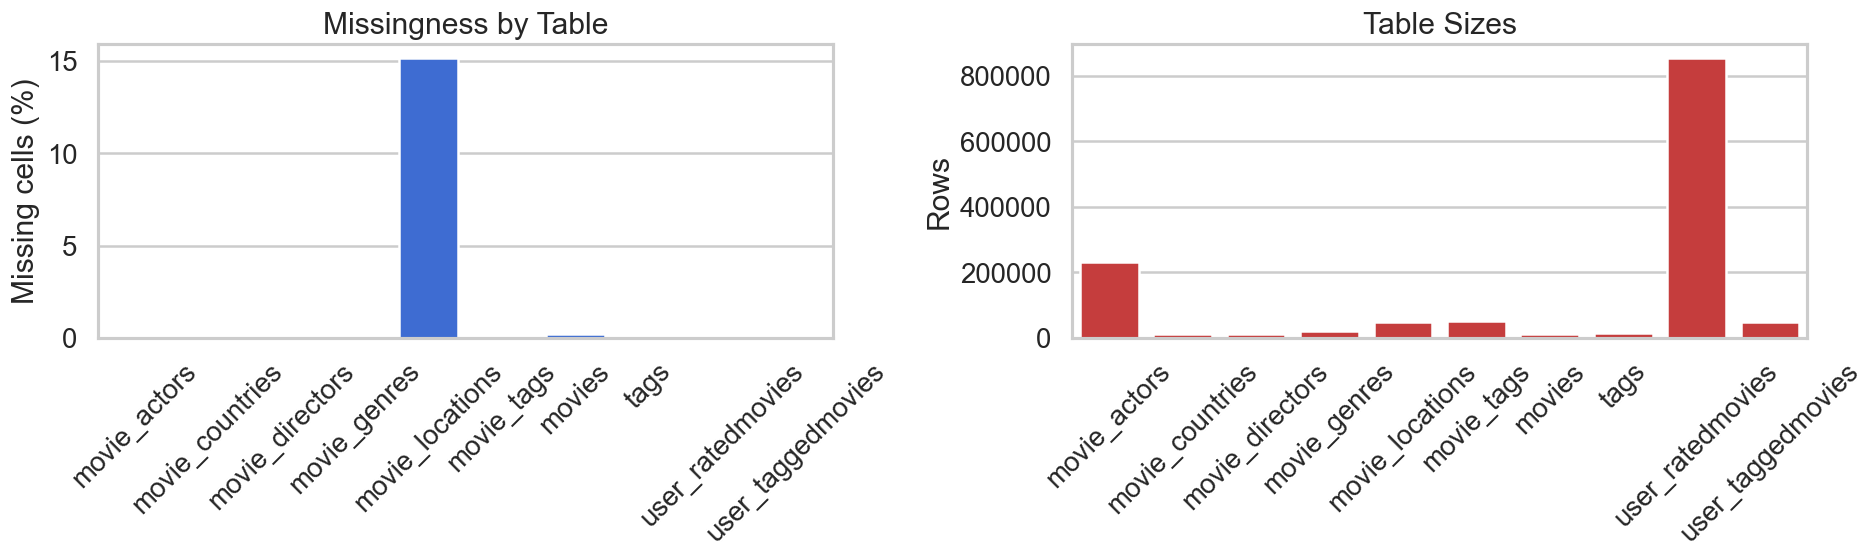

In [3]:
integrity = integrity_report(data)
display(integrity)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_pct = (overview["missing_cells"] / (overview["rows"] * overview["cols"])) * 100
sns.barplot(data=overview, x="table", y=missing_pct, ax=axes[0], color="#2563eb")
axes[0].set_title("Missingness by Table")
axes[0].set_ylabel("Missing cells (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=overview, x="table", y="rows", ax=axes[1], color="#dc2626")
axes[1].set_title("Table Sizes")
axes[1].set_ylabel("Rows")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Conclusions (Global Quality)

The dataset exhibits a classic recommender-system structure: an interaction table that is orders of magnitude larger than most metadata tables, plus multiple many-to-many relations that enrich movie descriptors. Missingness is concentrated in metadata fields rather than in the core relational IDs, which is favorable: the recommender can rely on stable identifiers and treat incomplete side information as a modeling limitation rather than a structural failure.

Integrity checks quantify whether any relation table points to non-existent movies or tags. In well-formed HetRec distributions, violations are typically near zero; nevertheless, explicitly measuring them is valuable because downstream feature engineering frequently assumes consistent coverage (e.g., merging `movie_tags` with `tags` to obtain human-readable tokens).

# 3. Exploratory Data Analysis of the Target: Ratings and Interaction Structure

In rating-prediction settings, the target variable is the explicit user rating. EDA must therefore answer:

- **What is the empirical rating distribution and its granularity?**  
- **How does interaction activity evolve over time (concept drift and non-stationarity)?**  
- **How sparse is the user–item matrix, and how skewed are user/movie activity distributions?**

These properties determine both the feasibility of latent-factor methods and the appropriate evaluation design (temporal splitting vs. random splitting).

,metric,value
0,count,855598.000
1,mean,3.438
2,median,3.500
3,p90,4.500
4,p95,5.000
5,p99,5.000
6,min,0.500
7,max,5.000


,metric,value
0,rows_total,855598
1,missing_event_time,0
2,min_event_time,1997-09-17 23:40:20
3,max_event_time,2009-01-05 05:32:20


,metric,value
0,users,2113.000000
1,movies,10109.000000
2,interactions,855598.000000
3,sparsity,0.959945
4,densitsy,0.040055


,metric,value
0,rows_total,855598
1,missing_rating,0
2,rating_below_0_5,0
3,rating_above_5,0
4,rating_not_half_step,0
5,duplicate_user_movie_pairs,0
6,suspicious_rows_total,0


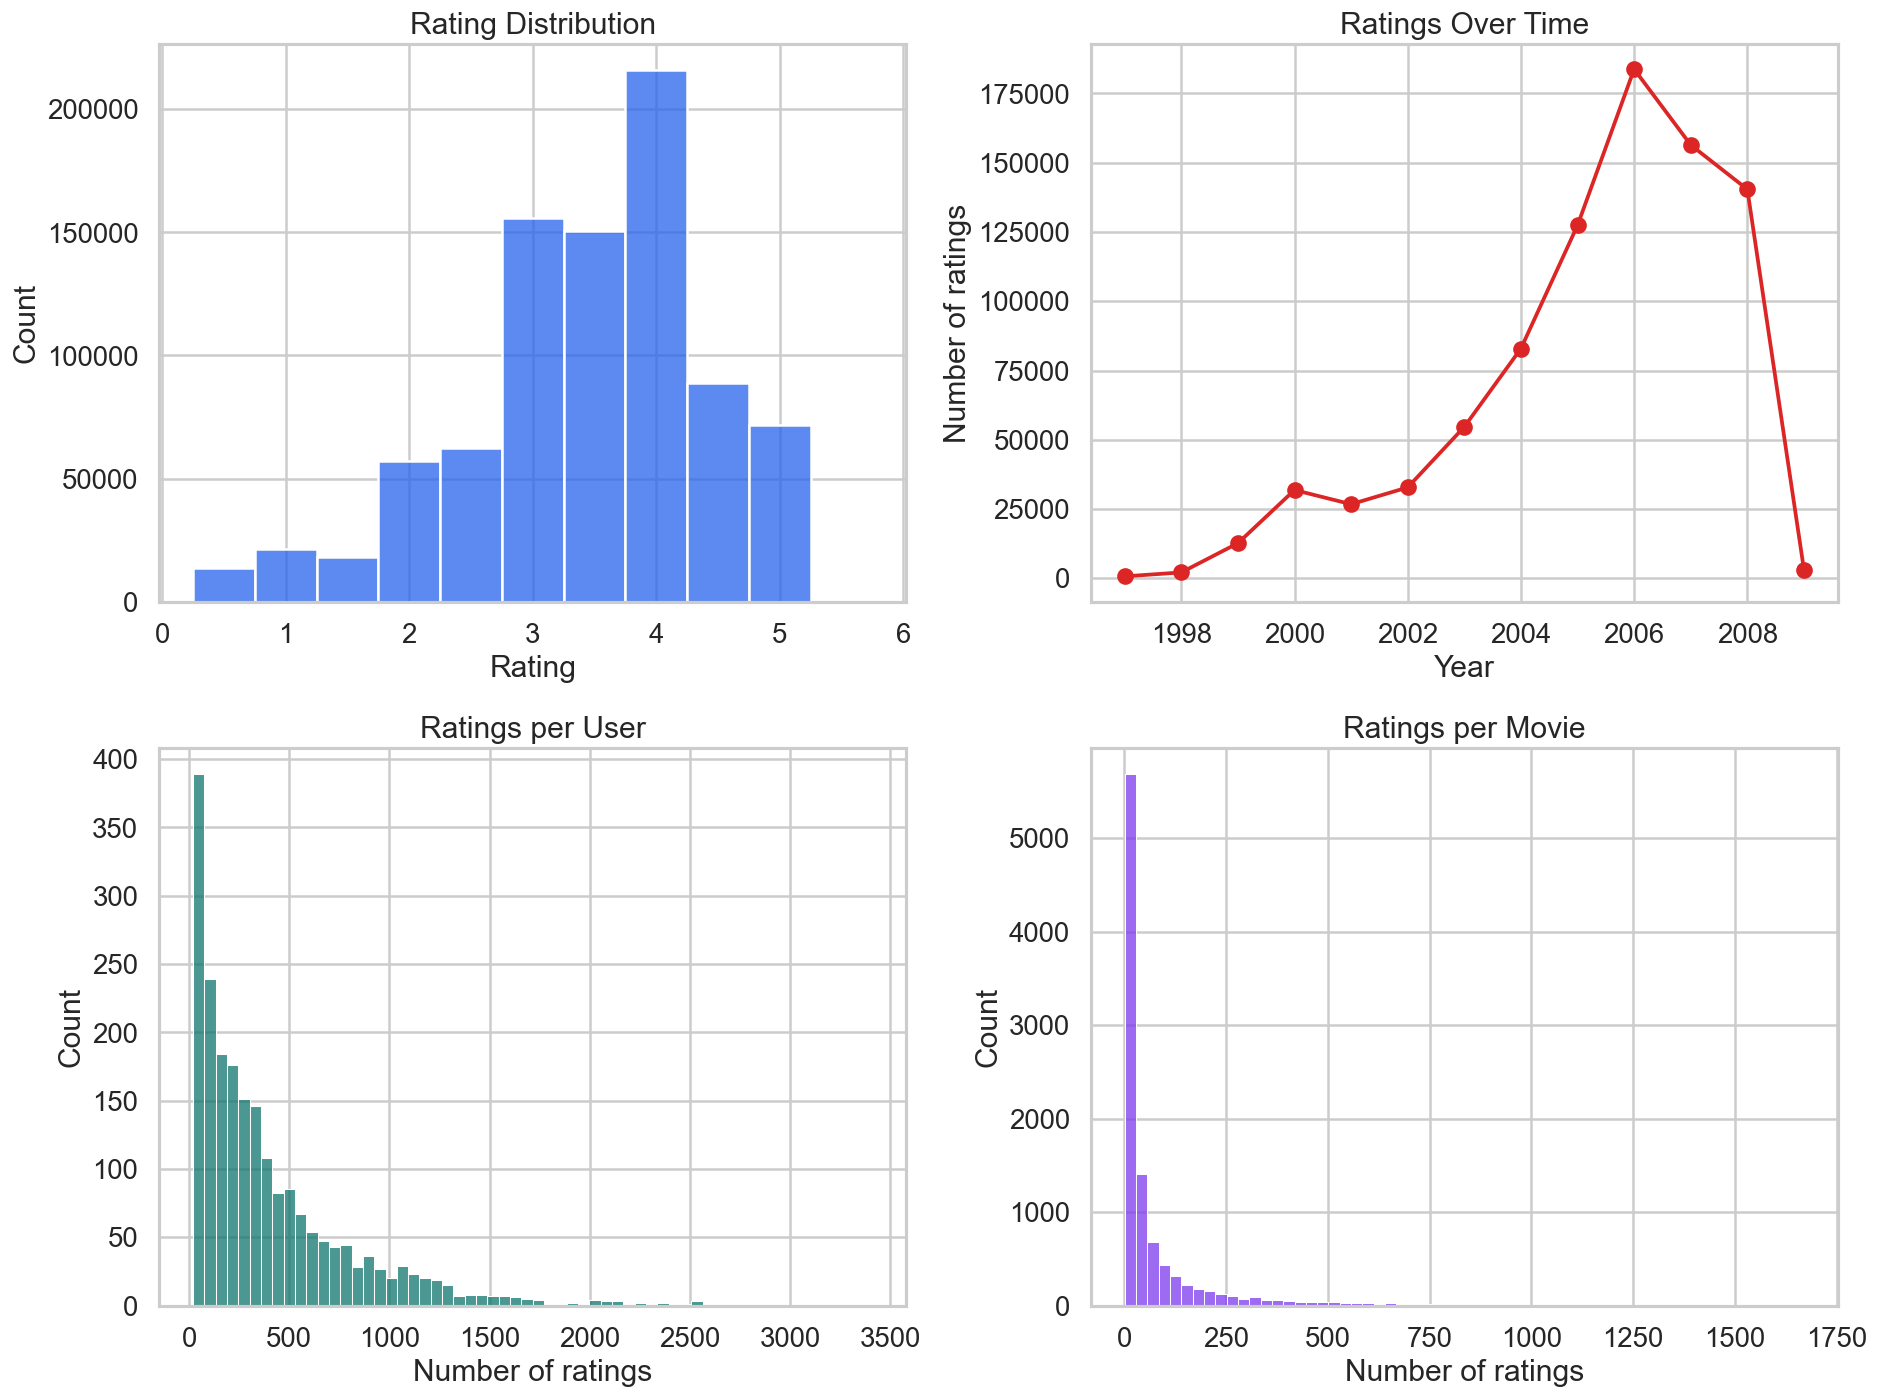

,metric,value
0,users,2113.000000
1,movies,10109.000000
2,interactions,855598.000000
3,density,0.040055
4,sparsity,0.959945


In [4]:
from src.eda.user_ratedmovies.checks import (
    rating_distribution_report,
    ratings_activity_report,
    ratings_time_report,
    suspicious_ratings_report,
)

dist_rep = rating_distribution_report(user_ratedmovies)
time_rep = ratings_time_report(user_ratedmovies)
activity_rep = ratings_activity_report(user_ratedmovies)
susp_rep = suspicious_ratings_report(user_ratedmovies)

display(dist_rep["summary"])
display(time_rep["summary"])
display(activity_rep["summary"])
display(susp_rep["summary"])

ratings_ts = build_timestamp_from_parts(user_ratedmovies)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(
    pd.to_numeric(user_ratedmovies["rating"], errors="coerce"),
    bins=np.arange(0.25, 5.76, 0.5),
    color="#2563eb",
    ax=axes[0, 0],
    edgecolor="white",
)
axes[0, 0].set_title("Rating Distribution")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")

ratings_by_year = ratings_ts.dt.year.value_counts().sort_index()
ratings_by_year.plot(ax=axes[0, 1], marker="o", color="#dc2626")
axes[0, 1].set_title("Ratings Over Time")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Number of ratings")

ratings_per_user = user_ratedmovies.groupby("userID").size()
sns.histplot(ratings_per_user, bins=60, color="#0f766e", ax=axes[1, 0], edgecolor="white")
axes[1, 0].set_title("Ratings per User")
axes[1, 0].set_xlabel("Number of ratings")

ratings_per_movie = user_ratedmovies.groupby("movieID").size()
sns.histplot(ratings_per_movie, bins=60, color="#7c3aed", ax=axes[1, 1], edgecolor="white")
axes[1, 1].set_title("Ratings per Movie")
axes[1, 1].set_xlabel("Number of ratings")

plt.tight_layout()
plt.show()

n_users = user_ratedmovies["userID"].nunique()
n_movies = user_ratedmovies["movieID"].nunique()
n_interactions = len(user_ratedmovies)
sparsity = 1 - (n_interactions / (n_users * n_movies))

pd.DataFrame(
    {
        "metric": ["users", "movies", "interactions", "density", "sparsity"],
        "value": [n_users, n_movies, n_interactions, 1 - sparsity, sparsity],
    }
)

## Conclusions (Ratings EDA)

The rating distribution typically concentrates on a discrete grid (half-star increments), which simplifies error interpretation: RMSE and MAE can be related to intuitive rating deviations (e.g., a 0.5-star miss). Temporal analysis is essential because recommender data is not i.i.d.; user tastes and catalog exposure evolve. Consequently, evaluation should prefer temporal splits to reduce the risk of training on interactions that occur after the test targets.

The user–item matrix is highly sparse: even with thousands of users and roughly ten thousand movies, observed interactions occupy a small fraction of possible pairs. This sparsity is not a nuisance artifact; it is a defining property that motivates latent-factor methods, careful regularization, and metrics that reflect real recommendation goals.

# 4. EDA of Side Information: Genres, Actors, Directors, Countries, Locations, and Tags

Side information serves two roles:

1. **Model performance:** content-based approaches and hybrid features can mitigate cold-start limitations and improve retrieval quality when explicit interactions are insufficient.  
2. **Interpretability:** explanations framed in human-readable attributes (genres, actors, tag words) are substantially more actionable than opaque latent dimensions.

EDA for side information therefore emphasizes:

- **coverage and skew** (e.g., long-tail distributions of actor appearances)
- **noise/outliers** (e.g., suspiciously short strings)
- **representational implications for feature engineering** (e.g., whether “top-N actors” is meaningful given ranking quality)

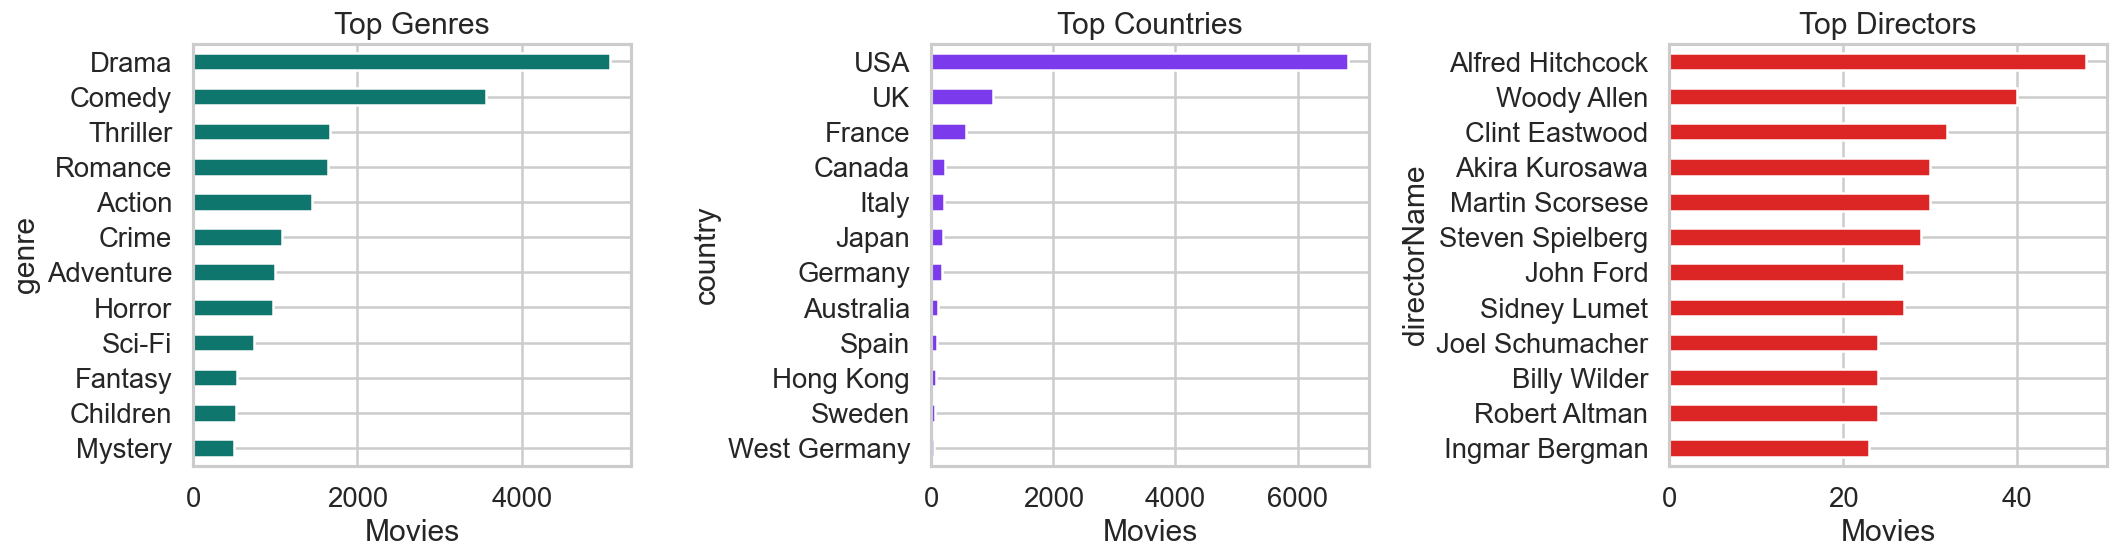

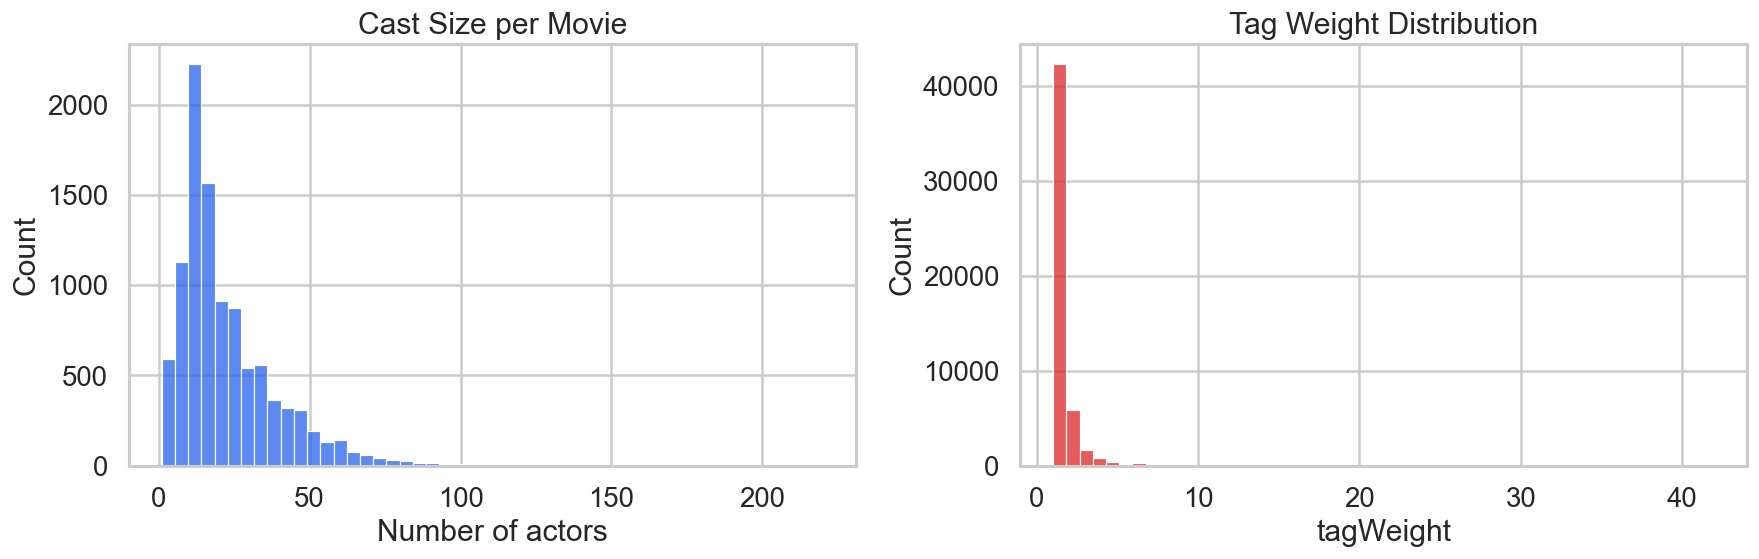

,metric,value
0,rows_total,231742
1,missing_actor_name,5
2,empty_or_whitespace_actor_name,0
3,very_short_actor_name_len_1_2,14
4,numeric_only_actor_name,0
5,suspicious_rows_total,19


,metric,value
0,rows_total,231742
1,missing_ranking,0
2,non_positive_ranking,0
3,non_integer_ranking,0
4,duplicate_ranking_within_movie_rows,4142
5,movies_with_non_contiguous_ranking,0


,metric,value
0,rows_total,20809
1,missing_genre,0
2,empty_or_whitespace_genre,0
3,one_character_genre,0
4,numeric_only_genre,0
5,suspicious_rows_total,0


,metric,value
0,rows_total,10155
1,missing_director_name,0
2,empty_or_whitespace_director_name,0
3,very_short_director_name_len_1_2,0
4,numeric_only_director_name,0
5,suspicious_rows_total,0


,metric,value
0,rows_total,10197
1,missing_country,8
2,empty_or_whitespace_country,0
3,numeric_only_country,0
4,one_character_country,0
5,suspicious_rows_total,8


,metric,value
0,rows_total,196668
1,missing_location_values,37308
2,empty_or_whitespace_values,0
3,numeric_only_values,0
4,one_character_values,0
5,suspicious_values_total,37308


,metric,value
0,rows_total,51795
1,missing_tag_weight,0
2,non_positive_tag_weight,0
3,non_integer_tag_weight,0
4,suspicious_rows_total,0
5,duplicate_movie_tag_pairs,0


,metric,value
0,rows_total,13222
1,missing_tag_value,0
2,empty_or_whitespace_tag_value,0
3,one_character_tag_value,0
4,numeric_only_tag_value,0
5,suspicious_rows_total,0


,metric,value
0,tags_total,13222.0
1,movie_tag_ids_total,5297.0
2,user_tag_ids_total,9079.0
3,movie_tag_coverage_pct,100.0
4,user_tag_coverage_pct,100.0
5,unused_tags_in_lookup,3281.0


In [5]:
from src.eda.movie_actors.checks import (
    actors_per_movie_report,
    movies_per_actor_report,
    ranking_imdb_order_report,
    suspicious_actor_report,
)
from src.eda.movie_countries.checks import suspicious_country_report
from src.eda.movie_directors.checks import suspicious_director_report
from src.eda.movie_genres.checks import suspicious_genre_report
from src.eda.movie_locations.checks import suspicious_location_report
from src.eda.movie_tags.checks import suspicious_movie_tags_report
from src.eda.tags.checks import suspicious_tag_report, tags_coverage_report

top_genres = movie_genres["genre"].value_counts().head(12).sort_values()
top_countries = movie_countries["country"].fillna("Unknown").value_counts().head(12).sort_values()
top_directors = movie_directors["directorName"].value_counts().head(12).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_genres.plot(kind="barh", ax=axes[0], color="#0f766e")
axes[0].set_title("Top Genres")
axes[0].set_xlabel("Movies")

top_countries.plot(kind="barh", ax=axes[1], color="#7c3aed")
axes[1].set_title("Top Countries")
axes[1].set_xlabel("Movies")

top_directors.plot(kind="barh", ax=axes[2], color="#dc2626")
axes[2].set_title("Top Directors")
axes[2].set_xlabel("Movies")

plt.tight_layout()
plt.show()

actor_counts = movie_actors.groupby("movieID").size()
tag_weight = pd.to_numeric(movie_tags["tagWeight"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(actor_counts, bins=50, color="#2563eb", ax=axes[0], edgecolor="white")
axes[0].set_title("Cast Size per Movie")
axes[0].set_xlabel("Number of actors")

sns.histplot(tag_weight.dropna(), bins=50, color="#dc2626", ax=axes[1], edgecolor="white")
axes[1].set_title("Tag Weight Distribution")
axes[1].set_xlabel("tagWeight")

plt.tight_layout()
plt.show()

display(suspicious_actor_report(movie_actors)["summary"])
display(ranking_imdb_order_report(movie_actors)["summary"])
display(suspicious_genre_report(movie_genres)["summary"])
display(suspicious_director_report(movie_directors)["summary"])
display(suspicious_country_report(movie_countries)["summary"])
display(suspicious_location_report(movie_locations)["summary"])
display(suspicious_movie_tags_report(movie_tags)["summary"])
display(suspicious_tag_report(tags_raw)["summary"])
display(tags_coverage_report(tags_raw, movie_tags, user_taggedmovies))

## Conclusions (Metadata EDA)

The distributions of genres, directors, actors, and tags typically exhibit strong long-tail behavior. This has immediate implications for representation choices: naive one-hot encodings of high-cardinality entities (actors, tags) can become extremely sparse and brittle, whereas carefully constrained summaries (e.g., “top-5 actors”, “top-10 tags”) provide stable and interpretable features.

Quality checks help justify specific engineering decisions. For example, if actor ranking contains gaps or duplicates for some movies, using only the top-ranked subset reduces sensitivity to ranking noise. Similarly, suspicious string entries (empty, numeric-only) should be treated as data-cleaning concerns, but in practice their impact can also be minimized through token filtering and robust aggregation.

# 5. Preprocessing and Leakage Control: Temporal Train/Test Split

To evaluate rating prediction honestly, we enforce a temporal split: the model is trained on interactions that occur earlier in time and evaluated on later interactions. This design prevents a subtle but common form of leakage: features computed from “future” ratings (relative to test interactions) would artificially inflate performance.

In this notebook, the temporal split is performed on the rating table. To keep the side-information stream consistent with the split, we also optionally restrict user tag events to the training period when building user-level tagging features.

In [6]:
train_ratings_raw, test_ratings_raw, cutoff_ts = temporal_split_by_timestamp(user_ratedmovies, test_fraction=TEST_FRACTION)

tag_ts = build_timestamp_from_parts(user_taggedmovies)
train_tagged_raw = user_taggedmovies.loc[tag_ts <= cutoff_ts].copy()

data_train = dict(data)
data_train["user_ratedmovies"] = train_ratings_raw
data_train["user_taggedmovies"] = train_tagged_raw

user_features, movie_features, interaction_features = build_all_features(data_train)

train_interactions = interaction_features[["userID", "movieID", "interaction_rating"]].copy()

test_interactions = test_ratings_raw[["userID", "movieID", "rating"]].rename(columns={"rating": "interaction_rating"}).copy()

pd.DataFrame(
    {
        "object": [
            "train_ratings_raw",
            "test_ratings_raw",
            "train_tagged_raw",
            "user_features",
            "movie_features",
            "interaction_features",
            "train_interactions",
            "test_interactions",
        ],
        "rows": [
            len(train_ratings_raw),
            len(test_ratings_raw),
            len(train_tagged_raw),
            len(user_features),
            len(movie_features),
            len(interaction_features),
            len(train_interactions),
            len(test_interactions),
        ],
        "columns": [
            train_ratings_raw.shape[1],
            test_ratings_raw.shape[1],
            train_tagged_raw.shape[1],
            user_features.shape[1],
            movie_features.shape[1],
            interaction_features.shape[1],
            train_interactions.shape[1],
            test_interactions.shape[1],
        ],
    }
)

Building user features...
  -> user_features: (1693, 15)
Building movie features...
  -> movie_features: (10197, 47)
Building interaction features...
  -> interaction_features: (684478, 27)


,object,rows,columns
0,train_ratings_raw,684478,9
1,test_ratings_raw,171120,9
2,train_tagged_raw,37576,9
3,user_features,1693,15
4,movie_features,10197,47
5,interaction_features,684478,27
6,train_interactions,684478,3
7,test_interactions,171120,3


# 6. Feature Engineering: Design Rationale, Documentation, and Empirical Behavior

Feature engineering is structured into three groups:

1. **User features** summarize rating behavior (volume, mean, variance, recency) and tagging engagement. These features contextualize individual rating tendencies (e.g., strict vs. lenient raters) and enable explanations that explicitly reference user behavior.  

2. **Movie features** quantify popularity (counts, means, variability), metadata richness (genre count, cast size), and auxiliary signals (Rotten Tomatoes availability, tag volume, location depth). These support both baselines and interpretability.  

3. **Interaction features** connect the user and the movie at the moment of rating: deviations from user/movie means, early-adopter signals, and sequence position within the user’s history.

A key design principle is human readability. Features are named and organized so that they can be used directly in interpretability methods (e.g., SHAP) without a post-hoc renaming layer.

,feature,group,dtype,description,shap_label
0,interaction_is_early_rater,interaction,int,1 if user rated within 1 year of release,Early rater
1,interaction_movie_age_at_rating,interaction,int,Movie age in years at the time of the rating,Movie age at rating
2,interaction_rating_vs_movie_avg,interaction,float,Rating minus movie's global mean (crowd deviat...,Rating vs movie avg
3,interaction_rating_vs_user_avg,interaction,float,Rating minus user's personal mean (personal de...,Rating vs user avg
4,interaction_user_rating_sequence,interaction,int,Position of this rating in user's history (1 =...,User rating sequence pos.
5,movie_age,movie,int,Years since release (at dataset end date),Movie age (years)
6,movie_avg_rating,movie,float,Mean rating across all users,Movie avg rating
7,movie_cast_size_capped,movie,int,Cast size capped at 50 (outlier-robust),Cast size
8,movie_director_experience,movie,int,Number of movies the director has made,Director experience
9,movie_genre_count,movie,int,Number of genres assigned to this movie,# genres


,n_features
group,
interaction,5
movie,14
user,10


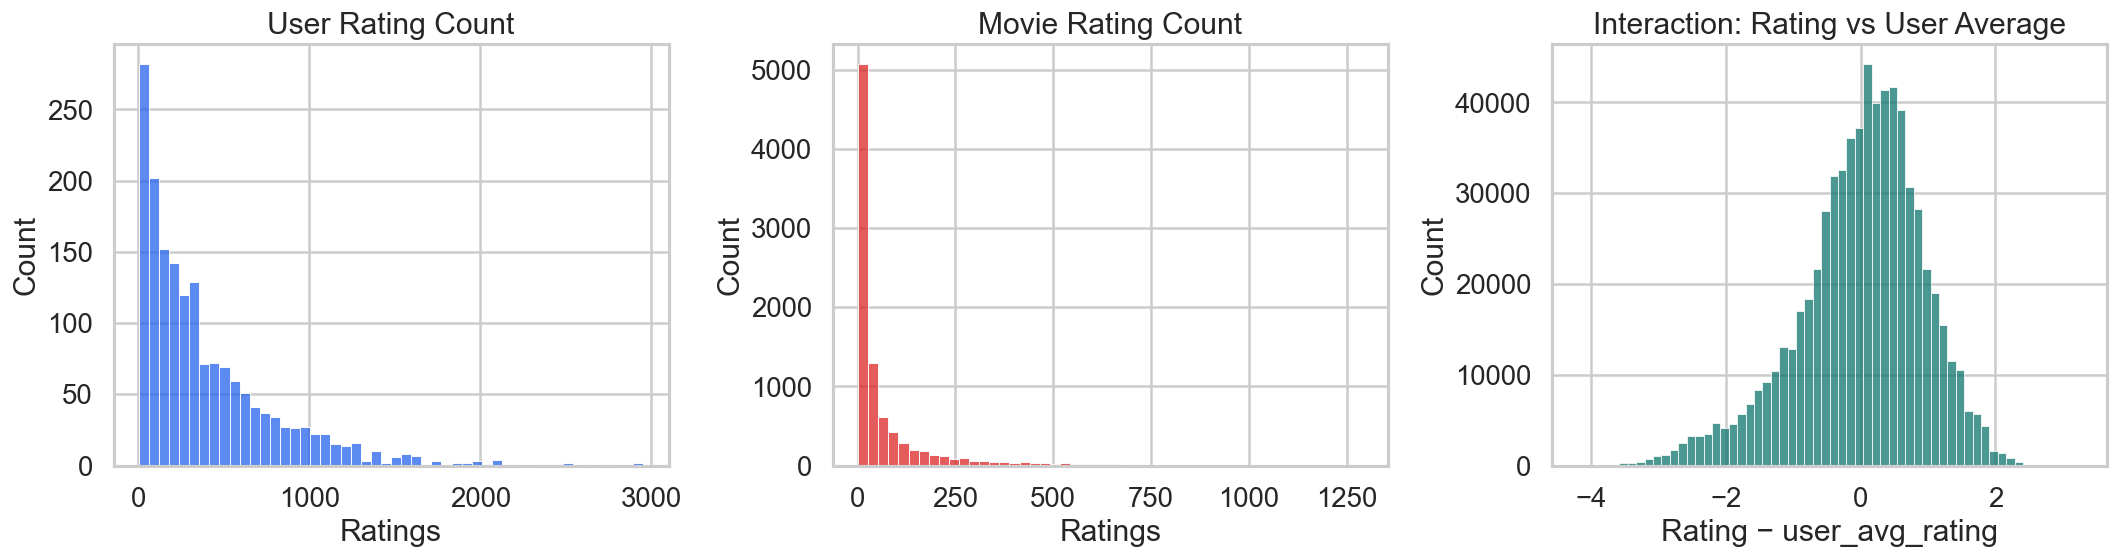

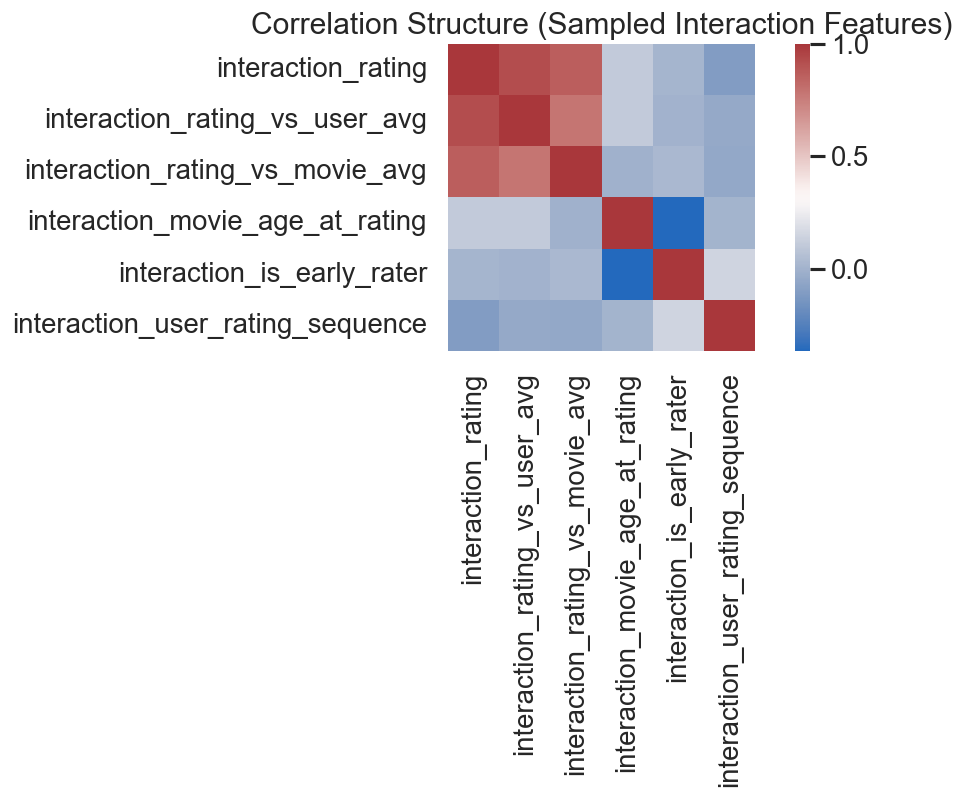

In [7]:
registry_df = (
    pd.DataFrame.from_dict(FEATURE_REGISTRY, orient="index")
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values(["group", "feature"])
    .reset_index(drop=True)
)
display(registry_df.head(20))

display(registry_df.groupby("group")["feature"].count().rename("n_features").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(user_features["user_rating_count"], bins=50, ax=axes[0], color="#2563eb", edgecolor="white")
axes[0].set_title("User Rating Count")
axes[0].set_xlabel("Ratings")

sns.histplot(movie_features["movie_rating_count"], bins=50, ax=axes[1], color="#dc2626", edgecolor="white")
axes[1].set_title("Movie Rating Count")
axes[1].set_xlabel("Ratings")

sns.histplot(
    interaction_features["interaction_rating_vs_user_avg"],
    bins=60,
    ax=axes[2],
    color="#0f766e",
    edgecolor="white",
)
axes[2].set_title("Interaction: Rating vs User Average")
axes[2].set_xlabel("Rating − user_avg_rating")

plt.tight_layout()
plt.show()

numeric_cols = [
    "interaction_rating",
    "interaction_rating_vs_user_avg",
    "interaction_rating_vs_movie_avg",
    "interaction_movie_age_at_rating",
    "interaction_is_early_rater",
    "interaction_user_rating_sequence",
]
sample_df = interaction_features[numeric_cols].dropna().sample(n=min(60_000, len(interaction_features)), random_state=SEED)

corr = sample_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="vlag", fmt=".2f", square=True, annot=False)
plt.title("Correlation Structure (Sampled Interaction Features)")
plt.tight_layout()
plt.show()

## Conclusions (Feature Engineering)

Empirically, user and movie activity counts are heavy-tailed: a minority of users provide many ratings, and a minority of movies attract a large share of interactions. This pattern is expected in recommender data and reinforces the importance of regularization and robust aggregation. Interaction deviations around user means provide a centered signal that reduces the confounding effect of user-specific rating scales; in practice, this is one reason why mean-centering is foundational to matrix factorization.

Correlation analysis should not be over-interpreted as causal, but it provides two useful validations. First, it checks that engineered features are not redundant copies of the target; second, it reveals whether certain features behave as intended (e.g., early-adopter indicators correlating with movie age-at-rating rather than trivially with the rating itself).

# 7. Modeling for Rating Prediction: Baselines and Collaborative Filtering

We evaluate rating prediction under a temporal split using RMSE and MAE:

- **MAE** measures the average absolute error in stars, which is directly interpretable.  
- **RMSE** penalizes large errors more strongly and is sensitive to outlier misses.

Before deploying complex models, we establish strong baselines:

1. **Global mean:** predict the same rating for all interactions.  
2. **Movie mean:** predict each movie’s historical mean rating (training period only).  
3. **User mean:** predict each user’s historical mean rating.  
4. **User–movie blended mean:** a simple combination of user and movie tendencies.

These baselines are intentionally transparent: they provide an interpretability anchor and a sanity check for evaluation integrity.

In [8]:
train_simple = train_ratings_raw[["userID", "movieID", "rating"]].copy()
test_simple = test_ratings_raw[["userID", "movieID", "rating"]].copy()

global_mean = float(train_simple["rating"].mean())
movie_mean = train_simple.groupby("movieID")["rating"].mean()
user_mean = train_simple.groupby("userID")["rating"].mean()

y_true = test_simple["rating"].astype(float).values

pred_global = np.full_like(y_true, fill_value=global_mean, dtype=float)
pred_movie = test_simple["movieID"].map(movie_mean).fillna(global_mean).astype(float).values
pred_user = test_simple["userID"].map(user_mean).fillna(global_mean).astype(float).values
pred_blend = (0.5 * pred_user + 0.5 * pred_movie).astype(float)

def rmse(y, p) -> float:
    return float(np.sqrt(mean_squared_error(y, p)))

def mae(y, p) -> float:
    return float(mean_absolute_error(y, p))

baseline_results = pd.DataFrame(
    {
        "model": ["Global mean", "Movie mean", "User mean", "User–movie blend"],
        "RMSE": [rmse(y_true, pred_global), rmse(y_true, pred_movie), rmse(y_true, pred_user), rmse(y_true, pred_blend)],
        "MAE": [mae(y_true, pred_global), mae(y_true, pred_movie), mae(y_true, pred_user), mae(y_true, pred_blend)],
    }
).sort_values("RMSE")

display(baseline_results)

,model,RMSE,MAE
1,Movie mean,0.876437,0.671771
3,User–movie blend,0.878378,0.677544
2,User mean,0.958793,0.742059
0,Global mean,0.969863,0.756399


## Baseline Interpretation

Baselines quantify how much predictive power is available from simple historical averages alone. Movie-mean and user-mean predictors often perform surprisingly well because they capture stable components of ratings: movies differ in global reception, and users differ in rating scale and leniency. Any collaborative model should therefore be judged by the extent to which it improves upon these averages without overfitting, especially under temporal evaluation where stationarity is imperfect.

# 8. Model A: Popularity Recommender (Non-Personalized)

## Rationale
A popularity recommender is an essential benchmark because it reflects a real product behavior: recommending globally strong and widely-liked items. It is also maximally interpretable—its logic can be stated directly (“high average rating with sufficient support”).

## Method
We rank movies using an IMDb-style weighted rating:

$$
\text{WR} = \frac{v}{v+m}R + \frac{m}{v+m}C
$$

where $R$ is the movie’s mean rating, $v$ is its rating count, $C$ is the global mean rating, and $m$ is a minimum-votes threshold.

## Strengths
- robust and simple  
- easy to explain  
- strong baseline in many settings  

## Limitations
- not personalized  
- amplifies popularity bias  
- weak for niche tastes and long-tail discovery

In [9]:
movies_metadata = movies_raw[["id", "title"]].rename(columns={"id": "movieID"}).copy()
movie_features_for_pop = movie_features[["movieID", "movie_avg_rating", "movie_rating_count"]].copy()

min_votes = 50
top_n = 10

pop_model = PopularityRecommender(min_votes=min_votes, top_n=top_n)
pop_model.fit(movie_features_for_pop, movies_metadata)

top_pop = pop_model.recommend()
display(top_pop)

Movies passing min_votes=50 threshold: 2870 / 10197


,movieID,title,movie_avg_rating,movie_rating_count,weighted_rating
0,318,The Shawshank Redemption,4.366757,1107.0,4.316396
1,858,The Godfather,4.336758,876.0,4.275453
2,50,The Usual Suspects,4.303758,958.0,4.249077
3,296,Pulp Fiction,4.251058,1181.0,4.208424
4,2959,Fight Club,4.235133,1093.0,4.189912
5,1193,One Flew Over the Cuckoo's Nest,4.234788,756.0,4.170682
6,4973,Le fabuleux destin d'Amélie Poulain,4.217861,879.0,4.163154
7,912,Casablanca,4.240196,612.0,4.161737
8,1221,The Godfather: Part II,4.225854,673.0,4.155007
9,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.223451,678.0,4.153255


# 9. Model B: Collaborative Filtering via Truncated SVD

## Theory
Collaborative filtering assumes that observed ratings can be explained by a small number of latent preference dimensions. SVD-based matrix factorization is a classical method:

- Construct a user–item matrix $X$ with missing values.  
- Mean-center each user’s ratings to remove user-scale effects.  
- Factorize the demeaned matrix into low-rank components.

## Implementation Details
- We use a sparse truncated SVD solver.  
- Predictions are reconstructed and then re-centered by adding user means back.  
- Evaluation uses RMSE and MAE on the temporally held-out test set.

## Strengths
- strong accuracy on dense-enough interaction data  
- efficient for moderate matrix sizes  
- conceptually simple  

## Limitations
- struggles with cold-start (new users/items)  
- latent factors are not directly human-interpretable  
- assumes approximate linear structure in the interaction matrix

In [10]:
svd_k = 30 if FAST_MODE else 50

svd_cf = SVDCollaborativeFiltering(n_factors=svd_k, random_state=SEED)
svd_cf.fit(train_interactions)

svd_results = svd_cf.evaluate(test_interactions)
svd_results

Step 1: Building user-item matrix...
User-item matrix shape: (1693, 9133)
Step 2: Mean-centering user ratings...
Step 3: Converting to sparse matrix...
Step 4: Running truncated SVD with k=30...
SVD factorization completed.
Step 5: Reconstructing predictions...
Prediction matrix created successfully.
Evaluating model on test set...
{'RMSE': np.float64(0.9207403756380594), 'MAE': np.float64(0.6873222587862974), 'Evaluated_Interactions': 51977}


{'RMSE': np.float64(0.9207403756380594),
 'MAE': np.float64(0.6873222587862974),
 'Evaluated_Interactions': 51977}

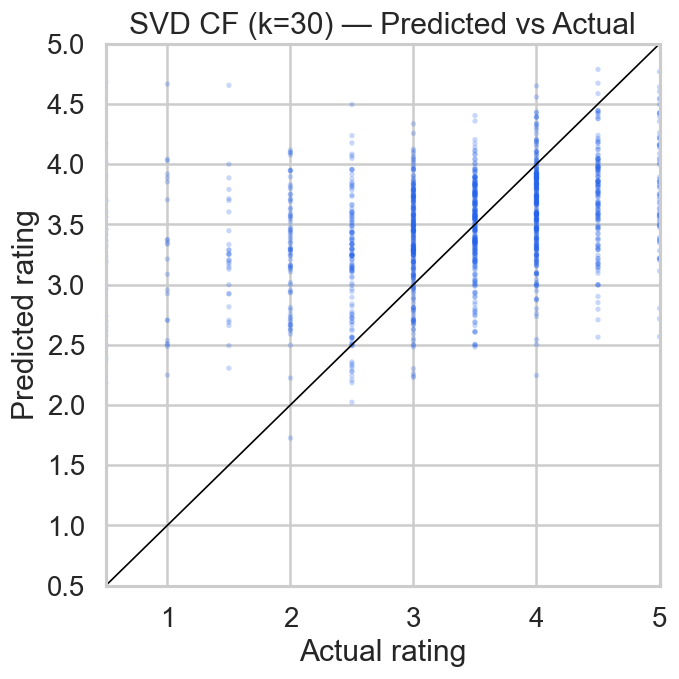

In [11]:
def predict_sample_scatter(model, df: pd.DataFrame, n: int = 4000, title: str = "") -> None:
    sample = df.sample(n=min(n, len(df)), random_state=SEED).copy()
    y = sample["interaction_rating"].astype(float).values
    p = np.array([model.predict_rating(row.userID, row.movieID) for row in sample.itertuples()], dtype=float)

    plt.figure(figsize=(6, 6))
    plt.scatter(y, p, s=10, alpha=0.25, color="#2563eb", edgecolor="none")
    plt.plot([0.5, 5.0], [0.5, 5.0], color="black", lw=1)
    plt.xlim(0.5, 5.0)
    plt.ylim(0.5, 5.0)
    plt.xlabel("Actual rating")
    plt.ylabel("Predicted rating")
    plt.title(title or "Predicted vs Actual (Sample)")
    plt.tight_layout()
    plt.show()

predict_sample_scatter(svd_cf, test_interactions, n=4000, title=f"SVD CF (k={svd_k}) — Predicted vs Actual")

## SVD Interpretation

A predicted-vs-actual scatter provides a qualitative diagnostic. Strong performance manifests as points concentrated along the diagonal. Systematic deviations (e.g., compressed predictions around the mean) often indicate that the model under-represents user extremes or that the low-rank approximation is too restrictive.

In practice, $k$ (the number of latent factors) controls the bias–variance trade-off: small $k$ is stable but may underfit; large $k$ increases capacity but risks fitting idiosyncratic historical noise, particularly under temporal splits.

# 10. Model C: SGD Matrix Factorization with Bias Terms

## Theory
A widely used factorization model predicts:

$$
\hat{r}_{ui} = \mu + b_u + b_i + p_u^\top q_i
$$

where $\mu$ is the global mean, $b_u$ and $b_i$ are user/item biases, and $p_u, q_i$ are latent vectors learned via SGD with regularization.

## Implementation Details
- SGD iterates over observed interactions.  
- Regularization controls overfitting in sparse regimes.  
- Bias terms capture stable offsets, improving accuracy and interpretability.

## Strengths
- strong empirical performance  
- additive structure enables exact contribution decomposition  
- flexible via learning rate, regularization, and factor count  

## Limitations
- training cost grows with interactions and epochs  
- latent factors require post-hoc interpretation  
- sensitive to hyperparameters without careful tuning

In [27]:
sgd_factors = 40 if FAST_MODE else 75
sgd_epochs = 8 if FAST_MODE else 25

sgd_cf = SGDMatrixFactorization(
    n_factors=sgd_factors,
    learning_rate=0.01,
    regularization=0.01,
    epochs=sgd_epochs,
    rating_min=0.5,
    rating_max=5.0,
    random_state=SEED,
)
sgd_cf.fit(train_interactions)

sgd_results = sgd_cf.evaluate(test_interactions)
sgd_results

Step 1: Preparing training data...
Users: 1693
Movies: 9133
Step 2: Initializing latent factors...
Step 3: Training model for 8 epochs...
Epoch 01/8 | Training RMSE: 0.8770
Epoch 05/8 | Training RMSE: 0.7553
Training completed successfully.
Evaluating model on test set...
{'RMSE': np.float64(0.9221), 'MAE': 0.711}


{'RMSE': np.float64(0.9221), 'MAE': 0.711}

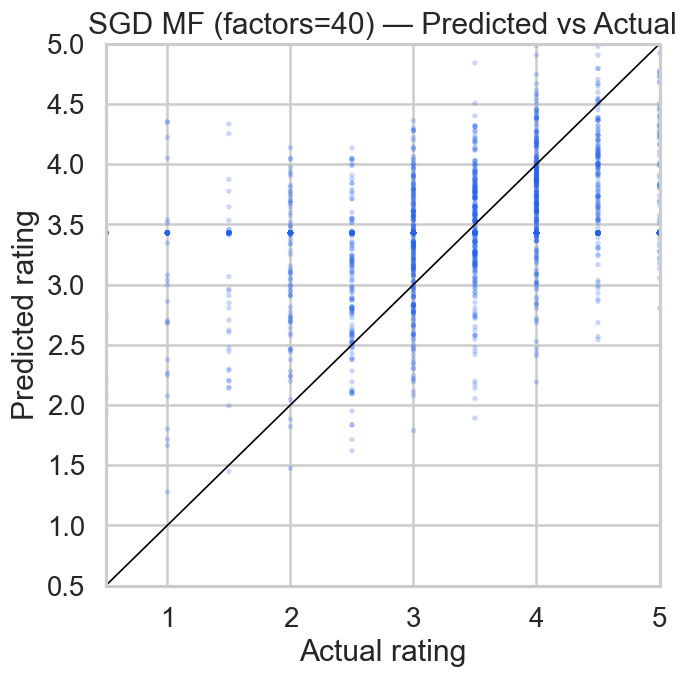

In [28]:
predict_sample_scatter(sgd_cf, test_interactions, n=4000, title=f"SGD MF (factors={sgd_factors}) — Predicted vs Actual")

# 11. Comparative Results (Rating Prediction)

We now aggregate baseline and collaborative filtering results into a single comparison table. The objective is not only to identify the best metric values, but to interpret why a model outperforms baselines: collaborative filtering can exploit cross-user and cross-item co-structure that simple averages cannot capture.

In [29]:
cf_results = pd.DataFrame(
    {
        "model": [f"SVD CF (k={svd_k})", f"SGD MF (factors={sgd_factors}, epochs={sgd_epochs})"],
        "RMSE": [float(svd_results["RMSE"]), float(sgd_results["RMSE"])],
        "MAE": [float(svd_results["MAE"]), float(sgd_results["MAE"])],
    }
)

results_all = pd.concat([baseline_results, cf_results], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
display(results_all)

,model,RMSE,MAE
0,Movie mean,0.876437,0.671771
1,User–movie blend,0.878378,0.677544
2,"SGD MF (factors=40, epochs=8)",0.922100,0.711000
3,SVD CF (k=30),0.929354,0.676568
4,User mean,0.958793,0.742059
5,Global mean,0.969863,0.756399


## Interpretation (Model Comparison)

Baselines capture stable first-order effects (user scale and movie reputation). Collaborative filtering models add value when user–item interactions exhibit consistent latent structure: users who co-rate similar subsets help infer preferences for unseen items.

However, improvements should be interpreted in context. A model with slightly better RMSE may still be inferior as a recommendation engine if it concentrates recommendations on a narrow popularity band or is hard to justify. This motivates including both ranking-based evaluation (in content-based recommendation) and explanation mechanisms (SHAP/LIME for token-level drivers; additive decomposition for latent factors).

# 12. Content-Based Recommendation via “Content Soups” and Embeddings

## Motivation
Content-based recommendation is particularly attractive when:

- users have limited interaction history (cold-start),  
- we want controllable similarity (e.g., “more movies like this”),  
- and we need explanations grounded in observable attributes.

## Representation
Each movie is assigned a single text-like string combining:

- genres (weighted by repetition),  
- director token,  
- top-N actors,  
- top-N tags (by tag weight).

We then embed these strings into a vector space and use cosine similarity to retrieve nearest neighbors.

## Reproducibility Choice
To avoid external downloads, we use TF-IDF vectors as embeddings by default. This yields a fully reproducible pipeline while preserving token-level interpretability. Dense sentence-transformer embeddings can be integrated in other environments, but they typically require downloading model weights, which is intentionally not assumed here.

In [30]:
genres_grouped = (
    movie_genres.groupby("movieID")["genre"]
    .apply(lambda x: " ".join(x.astype(str).str.replace(" ", "_")))
    .reset_index()
    .rename(columns={"genre": "genres_str"})
)

director_grouped = movie_directors.groupby("movieID")["directorName"].first().reset_index()
director_grouped["directorName"] = director_grouped["directorName"].astype(str).str.replace(" ", "_").str.lower()

top_actors = (
    movie_actors.loc[pd.to_numeric(movie_actors["ranking"], errors="coerce") <= 5]
    .groupby("movieID")["actorName"]
    .apply(lambda x: " ".join(x.astype(str).str.replace(" ", "_").str.lower()))
    .reset_index()
    .rename(columns={"actorName": "actors_str"})
)

movie_tags_named = movie_tags.merge(tags, on="tagID", how="left")
top_tags = (
    movie_tags_named.sort_values(["movieID", "tagWeight"], ascending=[True, False])
    .groupby("movieID")
    .head(10)
    .groupby("movieID")["tagValue"]
    .apply(lambda x: " ".join(x.astype(str).str.replace(" ", "_").str.lower()))
    .reset_index()
    .rename(columns={"tagValue": "tags_str"})
)

movie_profiles = movies[["movieID", "title", "year"]].copy()
movie_profiles = movie_profiles.merge(genres_grouped, on="movieID", how="left")
movie_profiles = movie_profiles.merge(director_grouped, on="movieID", how="left")
movie_profiles = movie_profiles.merge(top_actors, on="movieID", how="left")
movie_profiles = movie_profiles.merge(top_tags, on="movieID", how="left")

for col in ["genres_str", "directorName", "actors_str", "tags_str"]:
    movie_profiles[col] = movie_profiles[col].fillna("")

movie_profiles["content_soup"] = (
    movie_profiles["genres_str"]
    + " "
    + movie_profiles["genres_str"]
    + " "
    + movie_profiles["directorName"]
    + " "
    + movie_profiles["actors_str"]
    + " "
    + movie_profiles["tags_str"]
).str.strip()

movie_profiles_clean = movie_profiles.loc[movie_profiles["content_soup"].str.len() > 0].reset_index(drop=True)

tfidf_vec = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf_vec.fit_transform(movie_profiles_clean["content_soup"]).toarray().astype(np.float32)

norms = np.linalg.norm(X_tfidf, axis=1, keepdims=True)
embeddings = X_tfidf / np.maximum(norms, 1e-9)

title_to_index = build_title_to_index(movie_profiles_clean)

pd.DataFrame(
    {
        "metric": ["n_movies_profiles", "embedding_dim", "example_title", "example_soup_len"],
        "value": [
            len(movie_profiles_clean),
            embeddings.shape[1],
            movie_profiles_clean.iloc[0]["title"],
            len(movie_profiles_clean.iloc[0]["content_soup"]),
        ],
    }
)

,metric,value
0,n_movies_profiles,10197
1,embedding_dim,2000
2,example_title,Toy story
3,example_soup_len,254


In [31]:
_ = get_recommendations("Toy story", movie_profiles_clean, embeddings, title_to_index, n=10, verbose=True)


Because you liked: 'Toy story' (1995)
Genres: Adventure Animation Children Comedy Fantasy

Top 10 recommendations:
-----------------------------------------------------------------
#    Title                                    Year   Similarity
-----------------------------------------------------------------
1    Toy Story                                1995   0.9014
2    Once Upon a Forest                       1993   0.6077
3    Pokémon 4Ever                            2002   0.6077
4    Toy Story                                1995   0.6036
5    Digimon: Digital Monsters                1999   0.5631
6    The Polar Express                        2004   0.5470
7    Rugrats Go Wild                          2003   0.5438
8    The Phantom Tollbooth                    1970   0.5437
9    Niko - Lentäjän poika                    2008   0.5288
10   The Flight of Dragons                    1982   0.5255
-----------------------------------------------------------------


In [32]:
_ = get_recommendations("The Matrix", movie_profiles_clean, embeddings, title_to_index, n=10, verbose=True)


Because you liked: 'The Matrix' (1999)
Genres: Action Sci-Fi Thriller

Top 10 recommendations:
-----------------------------------------------------------------
#    Title                                    Year   Similarity
-----------------------------------------------------------------
1    The Matrix Reloaded                      2003   0.7868
2    The Matrix Revolutions                   2003   0.7750
3    TRON                                     1982   0.4783
4    Bill & Ted's Excellent Adventure         1989   0.4306
5    Hangar 18                                1980   0.4263
6    Permanent Record                         1988   0.4127
7    Johnny Mnemonic                          1995   0.4102
8    Nemesis 2: Nebula                        1995   0.3855
9    Fallout                                  1998   0.3850
10   Flash Gordon Conquers the Universe       1940   0.3850
-----------------------------------------------------------------


In [33]:
ratings_eval = user_ratedmovies[["userID", "movieID", "rating"]].copy()
ratings_eval_ts = build_timestamp_from_parts(user_ratedmovies)
ratings_eval = ratings_eval.assign(timestamp=ratings_eval_ts).sort_values(["userID", "timestamp"]).reset_index(drop=True)
ratings_eval = ratings_eval.loc[ratings_eval["timestamp"] <= cutoff_ts].drop(columns=["timestamp"]).copy()

sample_user = int(pd.Series(ratings_eval["userID"].unique()).sample(1, random_state=SEED).iloc[0])
_ = recommend_for_user(sample_user, ratings_eval, movie_profiles_clean, embeddings, n=10, min_rating=4.0, verbose=True)


User 53382 | rated 118 movies >= 4.0 stars
Sample liked: ['The Usual Suspects', 'Living in Oblivion', 'Smoke']

Top 10 recommendations:
-----------------------------------------------------------------
1    Tom and Jerry: The Movie                 1992   0.5205
2    The Doom Generation                      1995   0.5205
3    Indagine su un cittadino al di sopra di  1970   0.5086
4    Riri Shushu no subete                    2001   0.5086
5    The Learning Curve                       2001   0.5086
6    Camera Obscura                           2000   0.5086
7    The Business                             2005   0.5070
8    Beautiful Creatures                      2000   0.5035
9    O Homem Que Copiava                      2003   0.5022
10   Jigureul jikyeora!                       2003   0.5022
-----------------------------------------------------------------


## Interpretation (Content-Based Examples)

The content-based recommender retrieves neighbors that share high-overlap tokens in the constructed profile: repeated genre tokens, director identity, prominent actors, and frequent tags. Because the representation is explicit and the scoring function is cosine similarity, recommendations can be traced to shared attributes without requiring access to other users’ data. This makes the method particularly suitable for user-facing “because you liked…” explanations.

At the same time, the method inherits any biases in metadata coverage: if a movie has sparse tags or incomplete actor/director information, its embedding may be less informative. This is one reason the earlier metadata EDA matters: it determines how robustly “content” can stand in for preference.

# 13. Content-Based Evaluation: Precision@K, Coverage, and Diversity

Unlike rating prediction, content-based recommendation is naturally evaluated as a retrieval problem. We use:

- **Precision@K:** among the top-K recommendations, how many are relevant?  
- **Catalog coverage:** what fraction of the catalog appears in at least one user’s top-K list?  
- **Intra-list diversity:** how dissimilar are recommended items to each other (1 − mean pairwise similarity)?

To define relevance without an explicit ground-truth ranking, we treat a user’s high ratings as implicit positive feedback and hold out the last fraction of liked items within the training period.

In [34]:
rng = np.random.default_rng(SEED)
user_ids = pd.Series(ratings_eval["userID"].unique())
user_sample = user_ids.sample(n=min(250, len(user_ids)), random_state=SEED).tolist()

p_scores = []
for u in user_sample:
    p = precision_at_k(u, ratings_eval, movie_profiles_clean, embeddings, k=10, min_rating=4.0, test_frac=0.2)
    if p is not None:
        p_scores.append(p)

coverage = catalog_coverage(user_sample, ratings_eval, movie_profiles_clean, embeddings, k=10, min_rating=4.0)

query_title = "Toy story"
recs10 = get_recommendations(query_title, movie_profiles_clean, embeddings, title_to_index, n=10, verbose=False)
rec_indices = [int(title_to_index[t]) for t in recs10["title"].tolist() if t in title_to_index]
diversity = intra_list_diversity(rec_indices, embeddings)

eval_table = pd.DataFrame(
    {
        "metric": ["Precision@10 (mean)", "Precision@10 (std)", "Catalog coverage@10", "Intra-list diversity (example)"],
        "value": [
            float(np.mean(p_scores)) if p_scores else np.nan,
            float(np.std(p_scores)) if p_scores else np.nan,
            float(coverage),
            float(diversity) if diversity is not None else np.nan,
        ],
    }
)

display(eval_table)

,metric,value
0,Precision@10 (mean),0.000000
1,Precision@10 (std),0.000000
2,Catalog coverage@10,0.040992
3,Intra-list diversity (example),0.354672


## Evaluation Interpretation (Content-Based)

**Precision@K** is deliberately conservative here: it only credits a recommendation if it matches a held-out subset of a user’s previously liked items. This setup approximates a realistic “next liked item” retrieval task but does not capture novelty or serendipity.

**Coverage** provides a complementary perspective. A method can achieve high precision by repeatedly recommending the same small set of popular items, but such behavior is undesirable when discovery and long-tail exploration are goals. **Diversity** further diagnoses whether a list contains meaningful variety or collapses to near-duplicates in the embedding space.

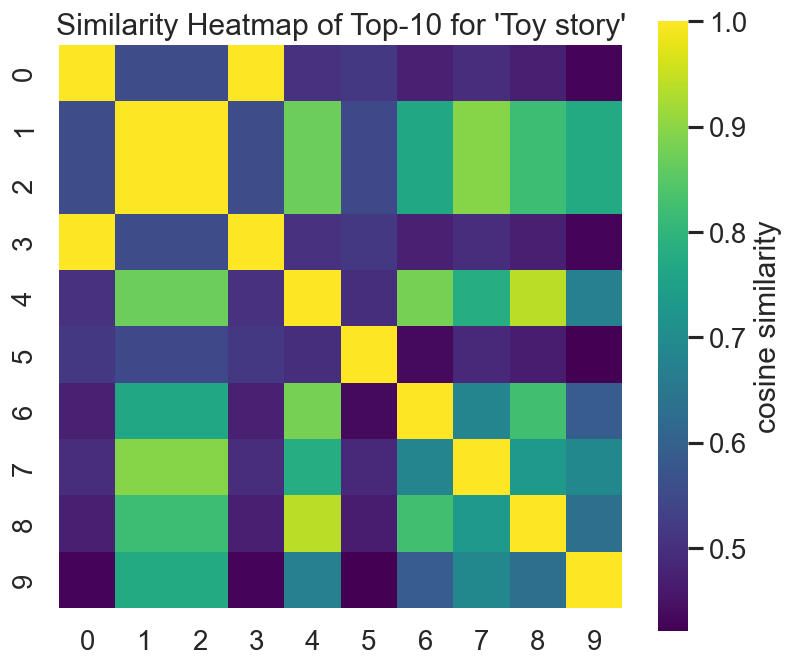

In [35]:
rec_titles = recs10["title"].tolist()
rec_idx = [int(title_to_index[t]) for t in rec_titles if t in title_to_index]
sub = embeddings[rec_idx]
sim = sub @ sub.T

plt.figure(figsize=(7, 6))
sns.heatmap(sim, cmap="viridis", square=True, cbar_kws={"label": "cosine similarity"})
plt.title(f"Similarity Heatmap of Top-10 for '{query_title}'")
plt.tight_layout()
plt.show()

# 14. Geometry of the Content Space: Low-Dimensional Visualization

To build intuition, we project high-dimensional embeddings to two dimensions. A direct t-SNE on 2000-D TF-IDF is expensive and noisy, so we first apply a linear compression (Truncated SVD) and then t-SNE.

This visualization is not an evaluation metric; it is a qualitative diagnostic. We expect movies with similar content soups (e.g., shared genres and tags) to cluster, reflecting a meaningful representation geometry.

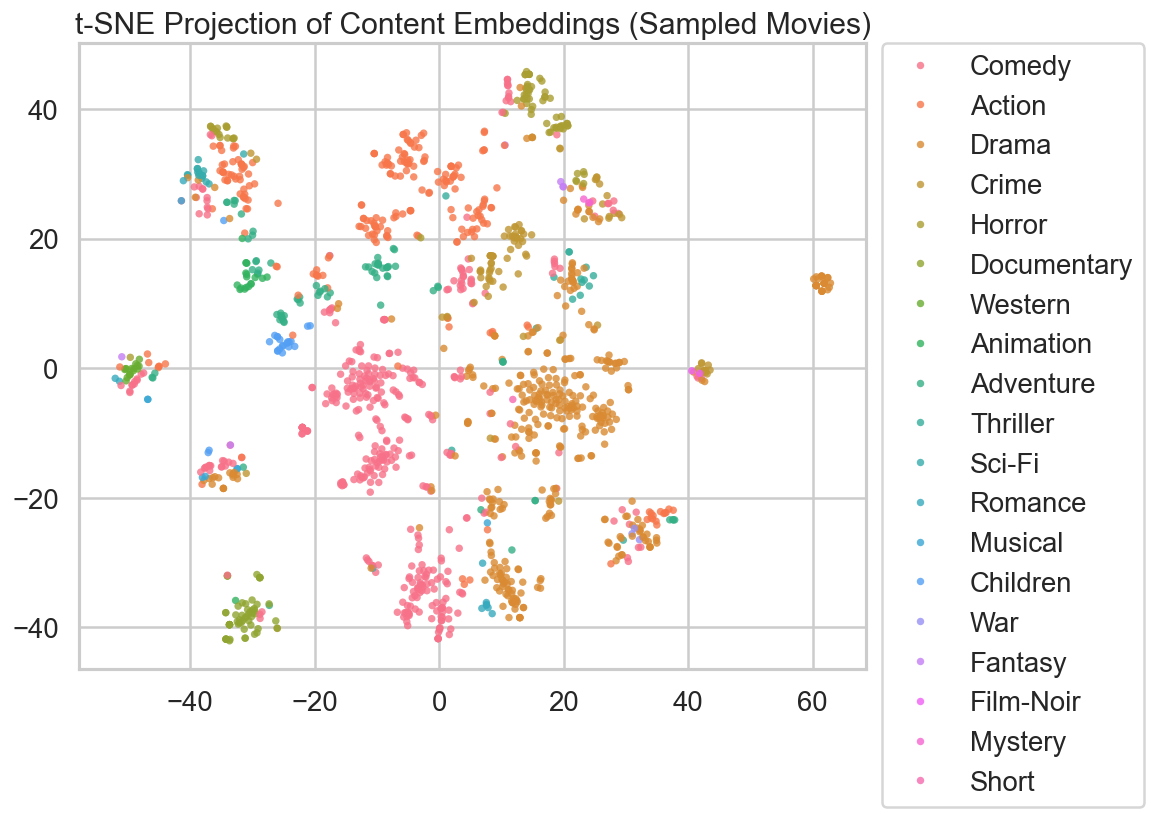

In [36]:
primary_genre = (
    movie_genres.groupby("movieID")["genre"]
    .agg(lambda x: x.iloc[0] if len(x) else "Unknown")
    .reset_index()
    .rename(columns={"genre": "primary_genre"})
)

viz_df = movie_profiles_clean.merge(primary_genre, on="movieID", how="left")
viz_df["primary_genre"] = viz_df["primary_genre"].fillna("Unknown")

idx = rng.choice(len(viz_df), size=min(1500, len(viz_df)), replace=False)

svd = TruncatedSVD(n_components=50, random_state=SEED)
X_red = svd.fit_transform(embeddings[idx])

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="random", random_state=SEED)
X_2d = tsne.fit_transform(X_red)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=viz_df.iloc[idx]["primary_genre"], s=20, alpha=0.8, linewidth=0)
plt.title("t-SNE Projection of Content Embeddings (Sampled Movies)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, ncol=1)
plt.tight_layout()
plt.show()

# 15. Explainability for Content-Based Retrieval (Surrogate + SHAP + LIME)

## Problem
Cosine similarity in an embedding space provides a score but not an explanation in human language. Even with TF-IDF, a user-facing explanation benefits from identifying which tokens drove similarity and in which direction.

## Strategy
We train an interpretable surrogate:

- Define a binary label “similar to query” based on top-N nearest neighbors under the retrieval model.  
- Train a classifier (Random Forest) on TF-IDF features to predict this label.  
- Use **SHAP** to obtain global and local feature attributions, and **LIME** to produce instance-level token importance for a specific recommendation.

This does not claim the surrogate is the recommender; rather, it is an explanation model designed to approximate the recommender’s decision boundary in a transparent space.

In [37]:
import shap
from lime import lime_text

QUERY = "Toy story"
if QUERY not in title_to_index:
    raise ValueError(f"Query title not found: {QUERY}")

q_idx = int(title_to_index[QUERY])
scores = embeddings @ embeddings[q_idx]
top_n = 100
top_idx = np.argsort(scores)[::-1][1 : top_n + 1]

y_labels = np.zeros(len(movie_profiles_clean), dtype=int)
y_labels[top_idx] = 1

X_words = tfidf_vec.transform(movie_profiles_clean["content_soup"]).toarray().astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(
    X_words, y_labels, test_size=0.2, random_state=SEED, stratify=y_labels
)

rf = RandomForestClassifier(n_estimators=250, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

report = pd.DataFrame(
    {
        "metric": ["train_acc", "test_acc", "positive_rate"],
        "value": [
            float((rf.predict(X_train) == y_train).mean()),
            float((rf.predict(X_test) == y_test).mean()),
            float(y_labels.mean()),
        ],
    }
)
display(report)

explainer = shap.TreeExplainer(rf)
X_shap = X_test[:300]
shap_values = explainer.shap_values(X_shap, check_additivity=False)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif np.ndim(shap_values) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

feature_names = tfidf_vec.get_feature_names_out()
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

,metric,value
0,train_acc,1.000000
1,test_acc,0.993627
2,positive_rate,0.009807


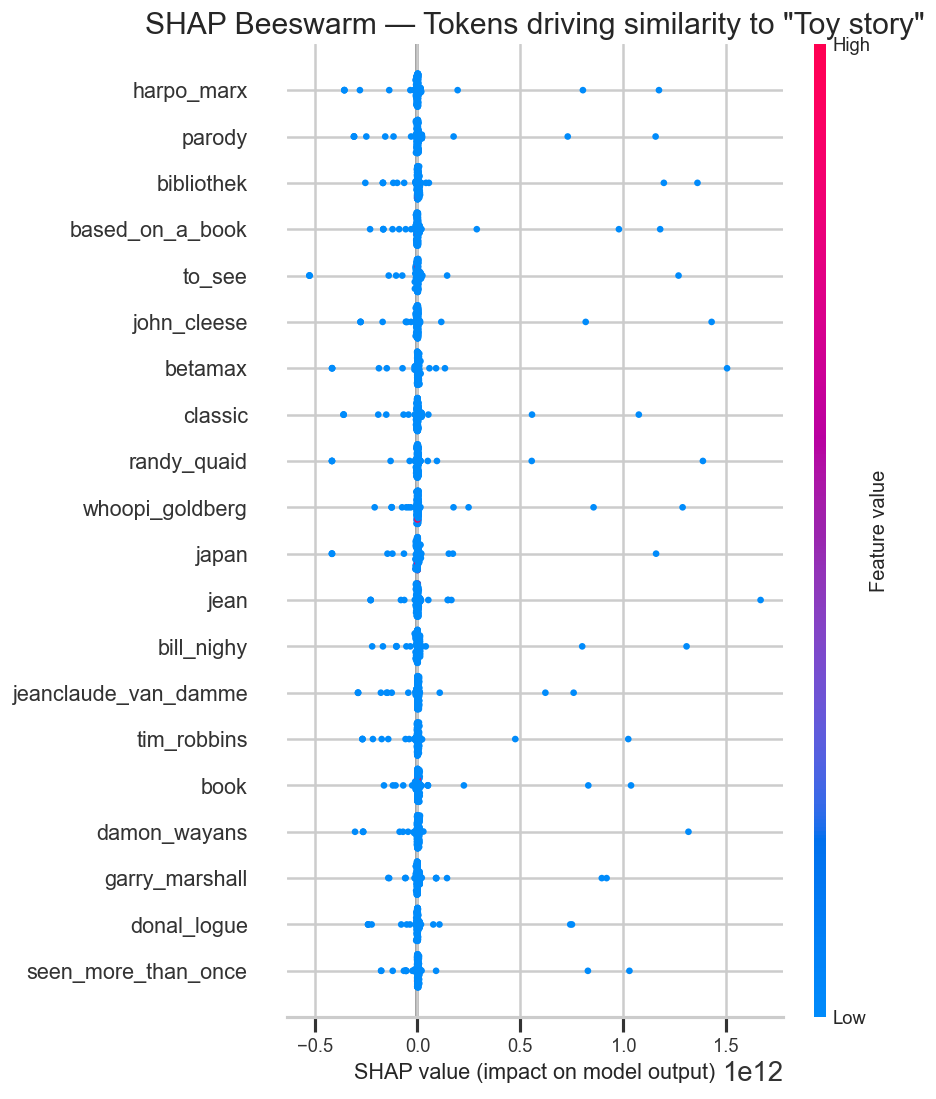

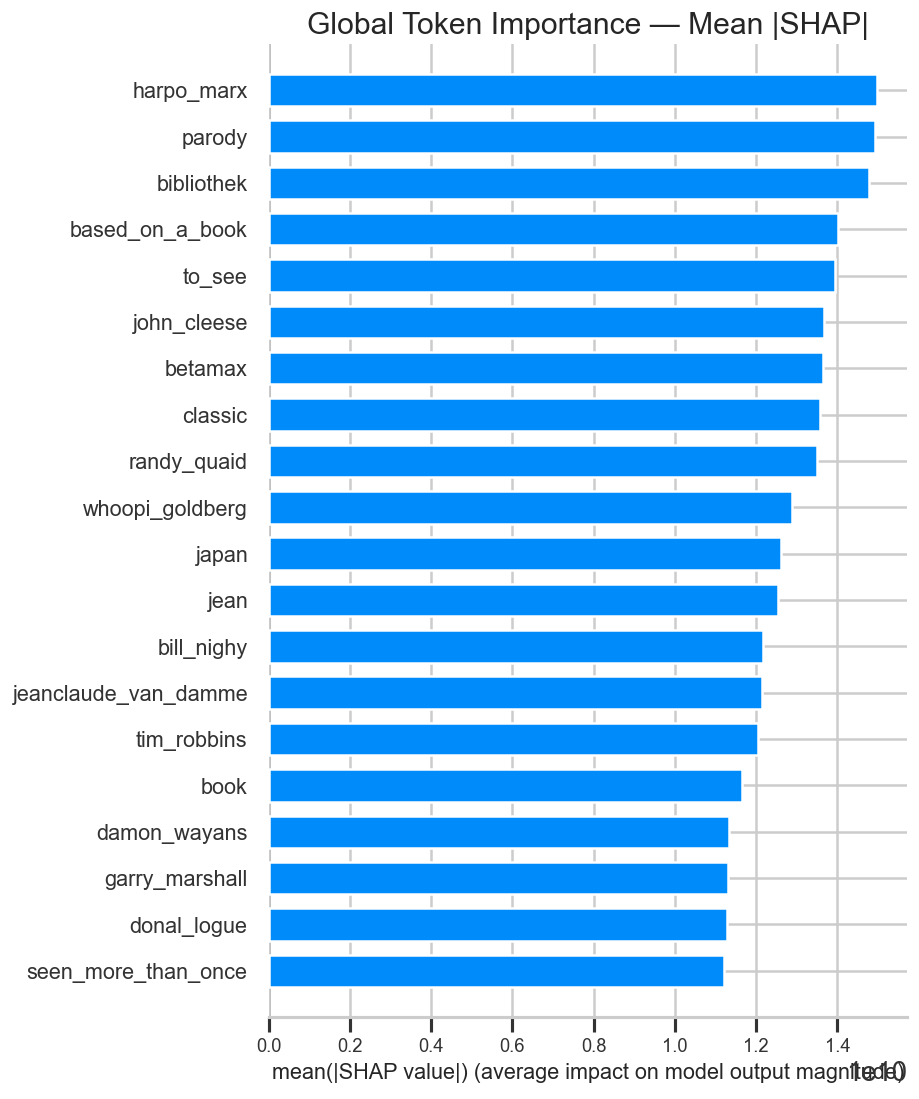

In [38]:
plt.figure(figsize=(11, 8))
shap.summary_plot(sv, X_shap_df, feature_names=list(feature_names), show=False)
plt.title(f'SHAP Beeswarm — Tokens driving similarity to "{QUERY}"')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_shap_df, feature_names=list(feature_names), plot_type="bar", show=False)
plt.title("Global Token Importance — Mean |SHAP|")
plt.tight_layout()
plt.show()

## Interpreting SHAP for the Surrogate

A SHAP summary plot provides a rigorous answer to: “Which tokens most strongly separate ‘similar to the query’ from ‘not similar’ under the surrogate?”

Tokens that reflect the query’s genre and distinctive metadata should appear with high attribution magnitude. Importantly, negative attributions are just as informative: they identify tokens whose presence pushes a movie away from the query’s neighborhood.

Because the surrogate is trained to mimic the top-N neighborhood, this explanation is aligned with retrieval behavior rather than with rating prediction. The attributions therefore describe semantic similarity in the engineered content space, not necessarily user preference.

,title,year,genres_str,similarity
1,Toy Story,1995,Adventure Animation Children Comedy Fantasy,0.9014
2,Once Upon a Forest,1993,Adventure Animation Children Fantasy,0.6077
3,Pokémon 4Ever,2002,Adventure Animation Children Fantasy,0.6077


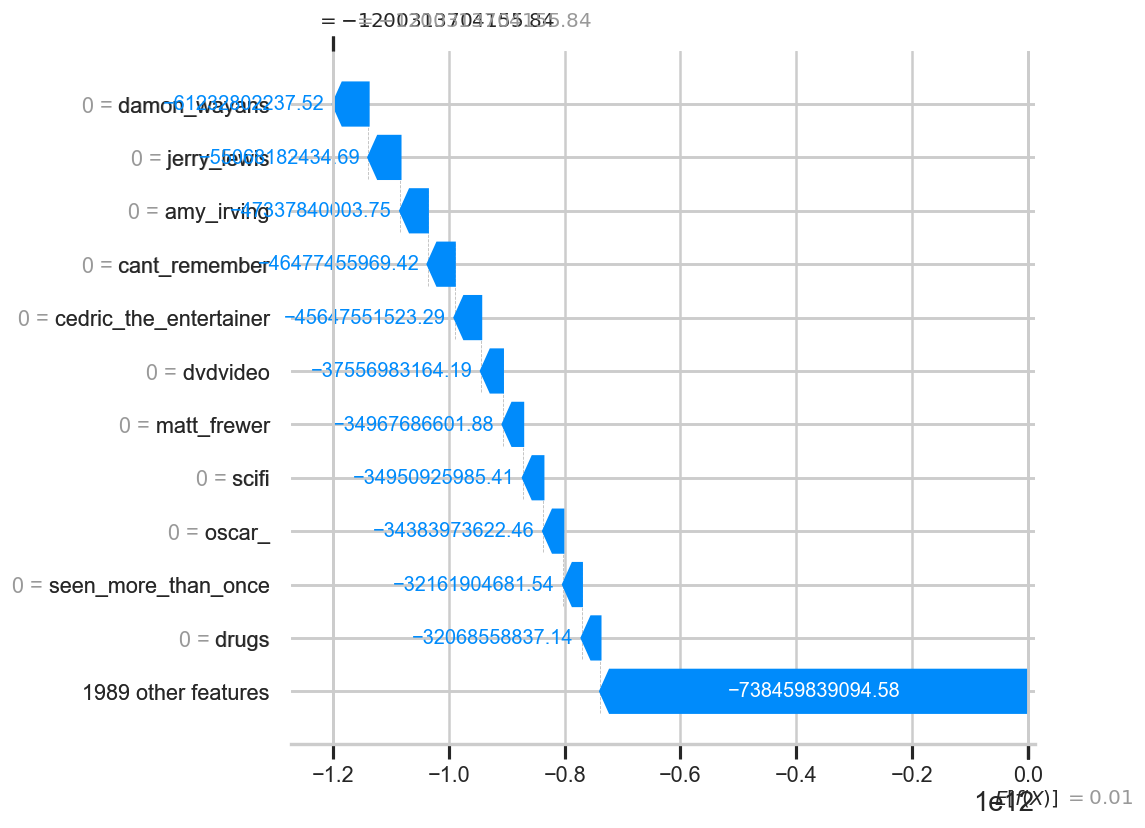

In [39]:
recs3 = get_recommendations(QUERY, movie_profiles_clean, embeddings, title_to_index, n=3, verbose=False)
display(recs3)

example_title = str(recs3.iloc[0]["title"])
example_idx = int(title_to_index[example_title])

x0 = tfidf_vec.transform([movie_profiles_clean.iloc[example_idx]["content_soup"]]).toarray().astype(np.float32)
sv0 = explainer.shap_values(x0, check_additivity=False)

if isinstance(sv0, list):
    sv0_c1 = sv0[1][0]
    base = float(explainer.expected_value[1])
elif np.ndim(sv0) == 3:
    sv0_c1 = sv0[0, :, 1]
    base = float(explainer.expected_value[1])
else:
    sv0_c1 = sv0[0]
    base = float(explainer.expected_value)

exp = shap.Explanation(
    values=sv0_c1,
    base_values=base,
    data=x0[0],
    feature_names=list(feature_names),
)
shap.plots.waterfall(exp, max_display=12, show=True)

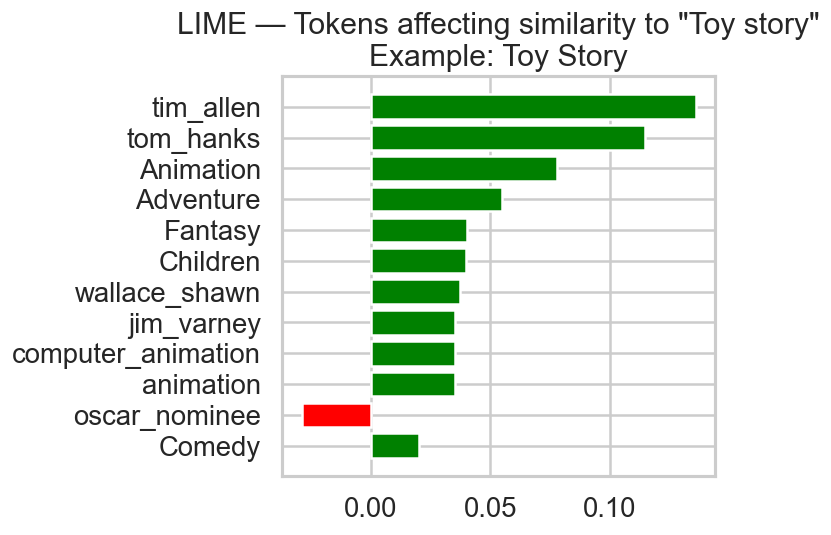

In [40]:
q_vec = embeddings[q_idx].astype(np.float32)

def lime_predict_fn(texts: list[str]) -> np.ndarray:
    X = tfidf_vec.transform(texts).toarray().astype(np.float32)
    X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-9)
    sims = np.clip(X @ q_vec, 0.0, 1.0)
    return np.column_stack([1.0 - sims, sims])

lime_explainer = lime_text.LimeTextExplainer(class_names=["not_similar", "similar"])

soup = movie_profiles_clean.iloc[example_idx]["content_soup"]
lime_exp = lime_explainer.explain_instance(
    soup,
    lime_predict_fn,
    num_features=12,
    labels=(1,),
)

fig = lime_exp.as_pyplot_figure(label=1)
plt.title(f'LIME — Tokens affecting similarity to "{QUERY}"\nExample: {example_title}')
plt.tight_layout()
plt.show()

# 16. Explainability for Collaborative Filtering (Exact Decomposition + SHAP Waterfall)

Latent-factor models are often criticized as “black boxes.” However, the SGD matrix factorization used here is exactly additive:

$$
\hat{r}_{ui} = \mu + b_u + b_i + \sum_k p_{u,k} q_{i,k}
$$

This allows us to explain a prediction by decomposing it into:

- global mean (dataset-wide baseline),  
- user bias (how the user deviates from the average),  
- item bias (how the item deviates from the average),  
- and a “taste match” term consisting of per-factor contributions.

We then visualize these contributions and optionally represent them as a SHAP-style waterfall for consistency with the earlier interpretability framework.

In [ ]:
USER_COL, ITEM_COL, TARGET_COL = "userID", "movieID", "interaction_rating"

if "movies_raw" in globals():
    _movies_src = movies_raw.copy()
elif "movies" in globals():
    _movies_src = movies.copy()
else:
    raise NameError("Missing `movies_raw` or `movies` in memory.")

_id_col = "id" if "id" in _movies_src.columns else ("movieID" if "movieID" in _movies_src.columns else None)
if _id_col is None:
    raise KeyError("Movie table doesn't have `id` or `movieID` column.")

if "title" not in _movies_src.columns:
    raise KeyError("Movie table doesn't have `title` column.")

movies_titles = _movies_src[[_id_col, "title"]].rename(columns={_id_col: "movieID"}).copy()

if "test_interactions" not in globals():
    raise NameError("Missing `test_interactions` (DataFrame with columns userID, movieID, interaction_rating).")

if "sgd_cf" not in globals():
    raise NameError("Missing `sgd_cf` (trained SGDMatrixFactorization).")

candidate_users = pd.Series(test_interactions[USER_COL].dropna().unique())
candidate_users = candidate_users[candidate_users.isin(getattr(sgd_cf, "user_to_idx", {}))]

if len(candidate_users) == 0:
    raise ValueError("No users from `test_interactions` found in the `sgd_cf` model.")

sample_user = int(candidate_users.sample(1, random_state=SEED).iloc[0])

recs = sgd_cf.recommend(sample_user, movies_titles, top_n=5)
display(recs.round({"predicted_rating": 3}))

valid_recs = recs[recs["movieID"].isin(getattr(sgd_cf, "movie_to_idx", {}))].copy()
if valid_recs.empty:
    raise ValueError("Model returned recommendations, but no `movieID` exists in `sgd_cf.movie_to_idx`.")

target_movie = int(valid_recs.iloc[0]["movieID"])
target_title = str(valid_recs.iloc[0]["title"])

u = sgd_cf.user_to_idx[sample_user]
i = sgd_cf.movie_to_idx[target_movie]

mu = float(sgd_cf.global_mean)
b_u = float(sgd_cf.user_biases[u])
b_i = float(sgd_cf.movie_biases[i])

factor_contrib = sgd_cf.user_factors[u] * sgd_cf.movie_factors[i]
taste_match = float(factor_contrib.sum())
predicted = mu + b_u + b_i + taste_match

pd.DataFrame(
    {
        "component": ["global mean", "user bias", "movie bias", "taste match (sum factors)", "predicted rating"],
        "value": [mu, b_u, b_i, taste_match, predicted],
    }
)

,movieID,title,predicted_rating
0,3090,Matewan,4.898
1,8582,Manufacturing Consent: Noam Chomsky and the Media,4.890
2,27815,Les choristes,4.882
3,5825,The Life and Death of Colonel Blimp,4.860
4,1232,Stalker,4.813


,component,value
0,global mean,3.429716
1,user bias,0.424009
2,movie bias,0.827121
3,taste match (sum factors),0.216673
4,predicted rating,4.897518


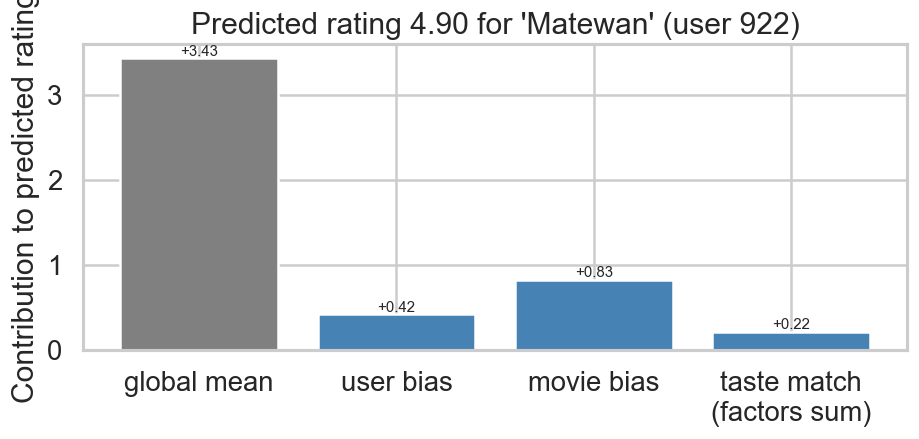

In [44]:
parts = ["global mean", "user bias", "movie bias", "taste match\n(factors sum)"]
values = [mu, b_u, b_i, float(factor_contrib.sum())]
colors = ["grey"] + ["steelblue" if v >= 0 else "tomato" for v in values[1:]]

plt.figure(figsize=(8, 4))
plt.bar(parts, values, color=colors, edgecolor="white")
plt.axhline(0, color="black", lw=0.8)
plt.title(f"Predicted rating {predicted:.2f} for '{target_title}' (user {sample_user})")
plt.ylabel("Contribution to predicted rating")
for x, v in enumerate(values):
    plt.text(x, v + (0.03 if v >= 0 else -0.07), f"{v:+.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

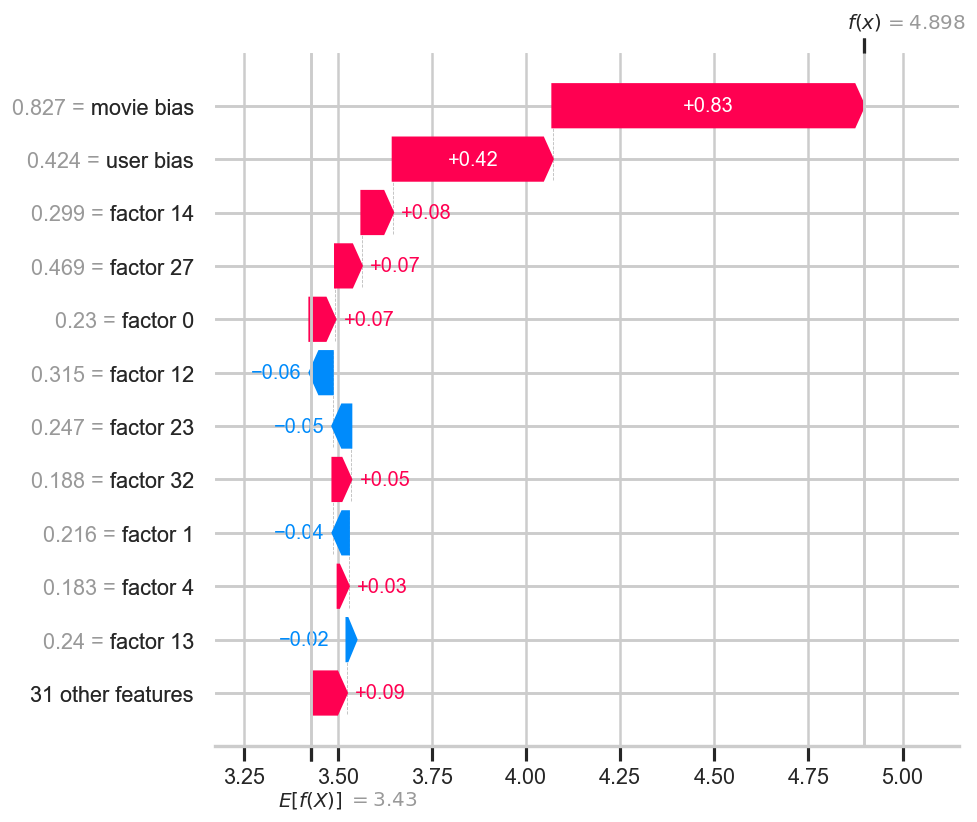

In [45]:
contrib_values = np.concatenate([[b_u, b_i], factor_contrib]).astype(float)
feat_names = ["user bias", "movie bias"] + [f"factor {k}" for k in range(len(factor_contrib))]
feat_data = np.concatenate([[b_u, b_i], sgd_cf.user_factors[u]]).astype(float)

explanation = shap.Explanation(
    values=contrib_values,
    base_values=float(mu),
    data=feat_data,
    feature_names=feat_names,
)
shap.plots.waterfall(explanation, max_display=12, show=True)

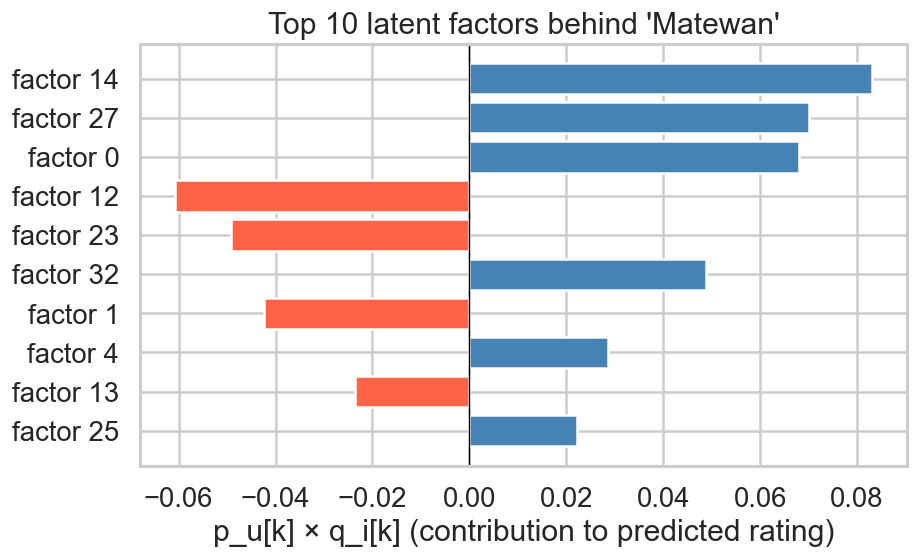

In [46]:
k_top = 10
order = np.argsort(np.abs(factor_contrib))[::-1][:k_top]
cols = ["steelblue" if factor_contrib[k] >= 0 else "tomato" for k in order]

plt.figure(figsize=(8, 5))
plt.barh(
    [f"factor {k}" for k in order][::-1],
    factor_contrib[order][::-1],
    color=cols[::-1],
    edgecolor="white",
)
plt.axvline(0, color="black", lw=0.8)
plt.title(f"Top {k_top} latent factors behind '{target_title}'")
plt.xlabel("p_u[k] × q_i[k] (contribution to predicted rating)")
plt.tight_layout()
plt.show()

In [47]:
seen = sgd_cf.train_df.loc[sgd_cf.train_df[USER_COL] == sample_user].copy()
seen = seen.loc[seen[ITEM_COL].isin(sgd_cf.movie_to_idx)].copy()

q_target = sgd_cf.movie_factors[i]

rows = []
for r in seen.itertuples():
    q_j = sgd_cf.movie_factors[sgd_cf.movie_to_idx[getattr(r, ITEM_COL)]]
    cos = float(np.dot(q_target, q_j) / (np.linalg.norm(q_target) * np.linalg.norm(q_j) + 1e-9))
    rows.append((getattr(r, ITEM_COL), getattr(r, TARGET_COL), cos))

neighbours = (
    pd.DataFrame(rows, columns=["movieID", "your_rating", "factor_similarity"])
    .merge(movies_titles, on="movieID", how="left")
    .sort_values("factor_similarity", ascending=False)
    .head(8)
    .reset_index(drop=True)
)

pd.DataFrame(
    {
        "statement": [f"'{target_title}' is recommended because your history contains factor-similar items."],
        "user_id": [sample_user],
        "target_movie": [target_title],
    }
)

display(neighbours[["title", "your_rating", "factor_similarity"]].round(3))

,title,your_rating,factor_similarity
0,The Beach,4.0,0.336
1,The Time Machine,3.5,0.323
2,Camp,5.0,0.301
3,Chicago,4.5,0.283
4,Don't Tell Mom the Babysitter's Dead,3.5,0.269
5,The Hours,4.0,0.263
6,Legally Blonde,4.0,0.261
7,Anacondas: The Hunt for the Blood Orchid,3.5,0.244


# 17. Discussion, Limitations, and Future Work

## Comparing Paradigms

**Popularity models** provide strong, stable, and easily defensible recommendations but cannot personalize.

**Collaborative filtering** improves personalization by exploiting cross-user structure, yet explanations require deliberate tooling (decomposition, neighbor reasoning, or post-hoc analyses).

**Content-based retrieval** is naturally explainable through shared attributes, supports cold-start scenarios, and offers controllable similarity behavior, but its quality depends on metadata coverage and representation choices.

## Evaluation Limitations

Offline metrics approximate but do not fully capture user experience. RMSE/MAE measure rating prediction accuracy, which correlates imperfectly with ranking utility. Precision@K based on held-out “liked” items captures retrieval behavior but does not measure novelty, serendipity, or calibration.

## Interpretability Limitations

- Surrogate explanations describe the surrogate’s approximation of retrieval neighborhoods, not an oracle truth.  
- Latent-factor contributions are exact mathematically, but mapping factors to human concepts remains non-trivial; neighbor-based reasoning provides a practical bridge.

## Future Work

- Hybrid modeling that integrates engineered user/movie features with interaction-based latent factors.  
- Calibration-aware ranking evaluation (NDCG@K, MAP@K) and popularity-bias diagnostics.  
- Robust explanation evaluation, including faithfulness tests and user studies.

# References

- Cantador, Iván; Brusilovsky, Peter; Kuflik, Tsvi. *2nd Workshop on Information Heterogeneity and Fusion in Recommender Systems (HetRec 2011), RecSys 2011.*

- GroupLens Research. *MovieLens datasets (and HetRec extensions).*

- Lundberg, Scott M.; Lee, Su-In. *A Unified Approach to Interpreting Model Predictions (SHAP).*

- Ribeiro, Marco T.; Singh, Sameer; Guestrin, Carlos. *"Why Should I Trust You?" Explaining the Predictions of Any Classifier (LIME).*